#I. Notebook Description: Data Processing and Dashboard Creation for Feedstuff Analysis

This notebook details the comprehensive process of loading, cleaning, and preparing feedstuff analysis data from four distinct subsets, followed by the compilation of aggregated dashboards for both gas production and nutritional values. Initially, data from CSV files for information samples, gas production, and nutrition are loaded into pandas DataFrames. A series of cleaning functions are then applied to standardize data, including removing header duplicates, normalizing ID suffixes (e.g., `-1`), enforcing consistent lab ID formats (e.g., FXX-XXXX), and mapping functional groups to a unified taxonomy (e.g., 'Grass', 'Shrub_Trees', 'Herbaceous_legumes'). SQL queries are used to join the cleaned information samples with gas production and nutrition data, generating sorted and consolidated DataFrames (e.g., `subset_X_gas_sorted_by_sql`, `subset_X_nutrition_sorted_by_sql`). These subset-specific DataFrames are subsequently concatenated into master DataFrames (e.g., `subsets_1_2_3_4_gas_sorted_by_sql`, `subsets_1_2_3_4_nutrition_sorted_by_sql`). Finally, dashboard-ready DataFrames are created by converting relevant columns to appropriate types and aggregating numerical features by `id` (calculating mean values) and retaining the first occurrence for categorical features, resulting in summarized datasets such as `subsets_1_2_3_4_gas_dashboard_complete` and `subsets_1_2_3_4_nutrition_dashboard_complete`.

# II. Libraries

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import sqlite3

# III. Cleaning functions

In [3]:
# Function to remove the first row (duplicated original column names)
def remove_first_row(df):
    return df.iloc[1:, :].copy()

# Usage:
# subset_1_information_samples = remove_first_row(subset_1_information_samples)

In [4]:
# Function to clean and standardize lab/sample IDs to FXX-XXXX format
def clean_lab_ids(series):
    return (
        series
        .astype(str)
        .str.replace(r'\s+', '-', regex=True)                 # Replace spaces with -
        .str.replace(r'^(F\d{2})(\d+)', r'\1-\2', regex=True) # Format FXX-XXXX
    )


# Usage:
# subset_1_information_samples['10_ciat_lab_id'] = clean_lab_ids(subset_1_information_samples['10_ciat_lab_id'])

In [5]:
# Function to clean and standardize Gene Bank - Breeding program IDs
def clean_standardize_ids(series):
    return (
        series
        .astype(str)
        .str.replace(r'-1$', '', regex=True)                   # Remove trailing -1
        .str.strip()                                           # Remove leading/trailing spaces
        .str.replace(r'[_\s]+', '-', regex=True)               # Replace spaces/underscores with -
        .str.replace(r'([A-Za-z])(\d)', r'\1-\2', regex=True)  # Letter followed by number
        .str.replace(r'(\d)([A-Za-z])', r'\1-\2', regex=True)  # Number followed by letter
        .str.replace(r'-+', '-', regex=True)                   # Remove repeated -
        .str.replace(r'^-|-$', '', regex=True)                 # Remove leading/trailing -
        .str.replace('ABC-', 'CIAT-', regex=False)             # Replace id's strings 'ABC' with 'CIAT'
    )

    # subset_1_information_samples['10_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_1_information_samples['10_gene_bank_breeding_program_id'])

# 1. Subset 1

## 1.1. Loading data

In [6]:
# Load the CSVs from Drive into pandas DataFrames
subset_1_information_samples = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_1/csv/10_information_samples.csv')
subset_1_gas_prod = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_1/csv/40g_result_gp_data_vf.csv')
subset_1_gas_ori = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_1/csv/31_gas_prod.csv')
subset_1_nutrition = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_1/csv/40n_result_nutrition_raw_data_vf.csv')
subset_1_digest = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_1/csv/32_digest.csv')

In [7]:
subset_1_gas_prod.to_csv('subset_1_gas_prod.csv')

## 1.2. Cleaning and formatting dataframes

In [8]:
# Clean first row containing orignal column names from excel files
subset_1_information_samples = remove_first_row(subset_1_information_samples)
subset_1_gas_prod = remove_first_row(subset_1_gas_prod)
subset_1_gas_ori = remove_first_row(subset_1_gas_ori)
subset_1_nutrition = remove_first_row(subset_1_nutrition)
subset_1_digest = remove_first_row(subset_1_digest)

# Add '-' to lab ids and ensure correct format FXX-XXXX
subset_1_information_samples['10_ciat_lab_id'] = clean_lab_ids(subset_1_information_samples['10_ciat_lab_id'])
subset_1_gas_prod['40g_ciat_id'] = clean_lab_ids(subset_1_gas_prod['40g_ciat_id'])
subset_1_gas_ori['31_ciat_id'] = clean_lab_ids(subset_1_gas_ori['31_ciat_id'])
subset_1_nutrition['40n_sample_id'] = clean_lab_ids(subset_1_nutrition['40n_sample_id'])
subset_1_digest['32_ciat_id'] = clean_lab_ids(subset_1_digest['32_ciat_id'])


# Clean and standardize gene bank and breeding program ids
subset_1_information_samples['10_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_1_information_samples['10_gene_bank_breeding_program_id'])
subset_1_gas_prod['40g_gene_bank_id'] = clean_standardize_ids(subset_1_gas_prod['40g_gene_bank_id'])
subset_1_gas_ori['31_gene_bank_id'] = clean_standardize_ids(subset_1_gas_ori['31_gene_bank_id'])
subset_1_nutrition['40n_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_1_nutrition['40n_gene_bank_breeding_program_id'])
subset_1_digest['32_gene_bank_id'] = clean_standardize_ids(subset_1_digest['32_gene_bank_id'])

In [9]:
# Check functional groups categories
subset_1_information_samples['10_functional_group'].unique()

array(['Herbaceous', 'Climber', 'Shrub', 'Tree', 'Grass', 'FAO', 'Legume',
       'Browse', 'Forage', 'Concentrate', 'Grasses', nan], dtype=object)

In [10]:
# Define the mapping for functional groups
functional_group_mapping = {
    'Grasses': 'Grass',
    'grasses': 'Grass',
    'Shrub': 'Shrub_Trees',
    'Shrub/tree': 'Shrub_Trees',
    'Shrub/Tree': 'Shrub_Trees',
    'Shrub/Trees': 'Shrub_Trees',
    'Shrub_Trees': 'Shrub_Trees',
    'Tree': 'Shrub_Trees',
    'Arbustiva ': 'Shrub_Trees',
    'Herbáceas': 'Herbaceous_legumes',
    'Herbáceas ': 'Herbaceous_legumes',
    'Herbaceous': 'Herbaceous_legumes',
    'Herbaceous legume': 'Herbaceous_legumes',
    'Climber': 'Herbaceous_legumes',
    'Legume': 'Herbaceous_legumes'
}

# Apply the mapping to centers datt
subset_1_information_samples['10_functional_group'] = subset_1_information_samples['10_functional_group'].replace(functional_group_mapping)

print('Updated functional group counts for subset_1_information_samples:')
display(subset_1_information_samples['10_functional_group'].value_counts())

Updated functional group counts for subset_1_information_samples:


,count
10_functional_group,
Herbaceous_legumes,145
Grass,72
Shrub_Trees,31
Concentrate,7
Forage,6
Browse,4
FAO,1


## 1.3. SQL query and dataframe creation

### 1.3.1. Gas

In [11]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_1_information_samples.to_sql('subset_1_information_samples', conn_new, if_exists='replace', index=False)
subset_1_gas_prod.to_sql('subset_1_gas_prod', conn_new, if_exists='replace', index=False)
subset_1_gas_ori.to_sql('subset_1_gas_ori', conn_new, if_exists='replace', index=False)
subset_1_digest.to_sql('subset_1_digest', conn_new, if_exists='replace', index=False)
print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [12]:
subset_1_information_samples.columns

Index(['10_sample_serial_no', '10_date  ', '10_requisitioner', '10_set_ciat',
       '10_ciat_lab_id', '10_gene_bank_breeding_program_id', '10_genus',
       '10_species', '10_tax_name', '10_family', '10_order',
       '10_functional_group', '10_remarks_1', '10_remarks_2'],
      dtype='object')

In [13]:
subset_1_digest.columns

Index(['32_no', '32_date', '32_gene_bank_id', '32_name', '32_ciat_id',
       '32_set_ciat', '32_batch', '32_run', '32_replication', '32_syrange_no',
       '32_bag_weight_g', '32_digested_weight_g', '32_remarks_1',
       '32_undigested_dm_g', '32_digested_feed_mg',
       '32_percentage_dmd_truly_digestibility', '32_ndf_incubated_mg',
       '32_ndf_digestibility_mg', '32_percentage_ndf_digestibility_in_24h',
       '32_remarks_2', 'Unnamed: 20', 'Unnamed: 21'],
      dtype='object')

In [14]:
subset_1_gas_prod.columns

Index(['40g_no', '40g_requisitioner', '40g_gene_bank_id', '40g_genus',
       '40g_species', '40g_tax_name', '40g_family', '40g_order',
       '40g_functional_group', '40g_ciat_id', '40g_set_ciat', '40g_batch',
       '40g_run', '40g_replication', '40g_ch4_8h_percentage',
       '40g_ch4_24h_percentage', '40g_net_gas_8h_ml', '40g_net_gas_24h_ml',
       '40g_gas_ml_g_dm_incubated_24h',
       '40g_percentage_dmd_truly_digestibility', '40g_part_fact',
       '40g_ch4_percentage_in_gas_8h', '40g_ch4_percentage_in_gas_24h',
       '40g_ch4_ml_g_dm_incubated_24h', '40g_ch4_ml_g_dmd_24h',
       '40g_ch4_ml_g_ndf_digested_in_24h', '40g_ch4_g_g_dm_incubated_24h',
       '40g_ch4_g_g_dmd_24h', '40g_remarks_1', '40g_remarks_2'],
      dtype='object')

In [15]:
subset_1_gas_ori.columns

Index(['31_no', '31_date', '31_requisitioner', '31_gene_bank_id', '31_genus',
       '31_species', '31_tax_name', '31_family', '31_order',
       '31_functional_group', '31_ciat_id', '31_set_ciat', '31_batch',
       '31_run', '31_replication', '31_syrange_no', '31_sample_weight_g',
       '31_dm_incubated_mg', '31_digested_feed_mg', '31_time_0h',
       '31_gas_0h_ml', '31_time_8h', '31_gas_8h_ml', '31_ch4_8h_percentage',
       '31_v8_push_back_ml', '31_time_24h', '31_gas_24h_ml',
       '31_ch4_24h_percentage', '31_remarks_1', '31_gp_8h_ml', '31_gp_8_24_ml',
       '31_net_gas_8h_ml', '31_net_gas_8_24h_ml2', '31_net_gas_24h_ml',
       '31_ch4_8h_ml', '31_ch4_8_24h_ml', '31_ch4_24h_ml',
       '31_gas_ml_g_dm_incubated_24h', '31_percentage_dmd_truly_digestibility',
       '31_part_fact', '31_ch4_ml_in_gas_8h', '31_ch4_ml_in_gas_24h',
       '31_ch4_ml_g_dm_incubated_24h', '31_ch4_ml_g_dmd_24h',
       '31_ch4_ml_g_ndf_digested_in_24h', '31_ch4_g_g_dm_incubated_24h',
       '31_ch4_g

In [16]:
query_combined = """
SELECT
    s1gc."40g_no" as no,
    s1i."10_requisitioner" as requisitioner,
    s1i."10_ciat_lab_id" as id_lab,
    s1i."10_gene_bank_breeding_program_id" as id,
    s1i."10_order" as tax_order,
    s1i."10_family" as family,
    s1i."10_genus" as genus,
    s1i."10_species" as species,
    s1i."10_tax_name" as tax_name,
    s1i."10_functional_group" as functional_group,

    s1gc."40g_set_ciat" as set_ciat,
    s1gc."40g_batch" as batch,
    s1gc."40g_run" as run,
    s1gc."40g_replication" as replication,
    s1gc."40g_replication" as syrange,

    s1go."31_sample_weight_g" as sample_weight_g,
    s1d."32_undigested_dm_g" as undigested_dm_g,
    s1go."31_dm_incubated_mg" as dm_incubated,
    s1go."31_digested_feed_mg" as digested_feed_mg,

    s1gc."40g_net_gas_8h_ml" as net_gas_8h_ml,
    s1gc."40g_net_gas_24h_ml" as net_gas_24h_ml,
    s1go."31_ch4_8h_ml" as ch4_8h_ml,
    s1go."31_ch4_24h_ml" as ch4_24h_ml,
    s1gc."40g_ch4_percentage_in_gas_8h" as ch4_percentage_in_gas_8h,
    s1gc."40g_ch4_percentage_in_gas_24h" as ch4_percentage_in_gas_24h,

    s1gc."40g_gas_ml_g_dm_incubated_24h" as gas_ml_g_dm_incubated_24h,
    s1gc."40g_part_fact" as part_fact,

    s1gc."40g_ch4_ml_g_dm_incubated_24h" as ch4_ml_g_dm_incubated_24h,
    s1gc."40g_ch4_ml_g_ndf_digested_in_24h" as ch4_ml_g_ndf_digested_24h,
    s1gc."40g_ch4_ml_g_dmd_24h" as methane_intensity,
    s1gc."40g_percentage_dmd_truly_digestibility" as tddm,

    s1i."10_remarks_1" as information_remarks_1,
    s1i."10_remarks_2" as information_remarks_2,
    s1gc."40g_remarks_1" as gas_remarks_1,
    s1gc."40g_remarks_2" as gas_remarks_2,
    s1d."32_remarks_1" as digest_remarks_1,
    s1d."32_remarks_2" as digest_remarks_2

FROM
    subset_1_information_samples AS s1i
JOIN
    subset_1_gas_ori AS s1go
ON s1i."10_ciat_lab_id" = s1go."31_ciat_id"

JOIN subset_1_gas_prod AS s1gc
ON s1go."31_gene_bank_id" = s1gc."40g_gene_bank_id"
AND s1go."31_batch" = s1gc."40g_batch"
AND s1go."31_replication" = s1gc."40g_replication"

LEFT JOIN subset_1_digest AS s1d
ON s1go."31_ciat_id" = s1d."32_ciat_id"
AND s1go."31_batch" = s1d."32_batch"
AND s1go."31_replication" = s1d."32_replication"


ORDER BY
    CAST(no AS INTEGER) ASC

"""

subset_1_gas_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_1_gas_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
0,#REF!,LMF,F25-0017,Hohenheimer-Heustandard,Forage,Forage,Hohenheimer,Heustandard,Hohenheimer Heustandard,Forage,...,33.24064574,0,95.43754089,34.82973831,Standar,None,None,None,None,None
1,#REF!,LMF,F25-0017,Hohenheimer-Heustandard,Forage,Forage,Hohenheimer,Heustandard,Hohenheimer Heustandard,Forage,...,32.48546917,0,89.75200777,36.19469912,Standar,None,None,None,None,None
2,#REF!,LMF,F25-0017,Hohenheimer-Heustandard,Forage,Forage,Hohenheimer,Heustandard,Hohenheimer Heustandard,Forage,...,33.70505251,0,59.21398025,56.92076832,Standar,None,None,None,None,None
3,#REF!,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,Concentrate,...,44.140303,0,70.13200392,62.93888743,Standar,None,None,None,None,None
4,#REF!,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,Concentrate,...,42.17957456,0,70.45327289,59.86886462,Standar,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,1629,LMF,F25-0019,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,16.20936672,0,49.48351384,32.75710527,Standar,None,None,None,None,None
2180,1629,LMF,F25-0019,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,16.20936672,0,49.48351384,32.75710527,Standar,None,None,None,None,None
2181,1629,LMF,F25-0019,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,16.20936672,0,49.48351384,32.75710527,Standar,None,None,None,None,None
2182,1629,LMF,F25-0019,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,16.20936672,0,49.48351384,32.75710527,Standar,None,None,None,None,None



SQLite connection closed.


In [17]:
# Remove duplicate rows, keeping the first occurrence
subset_1_gas_sorted_by_sql = subset_1_gas_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_1_gas_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_1_gas_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (1938, 37)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
0,#REF!,LMF,F25-0017,Hohenheimer-Heustandard,Forage,Forage,Hohenheimer,Heustandard,Hohenheimer Heustandard,Forage,...,33.24064574,0,95.43754089,34.82973831,Standar,None,None,None,None,None
1,#REF!,LMF,F25-0017,Hohenheimer-Heustandard,Forage,Forage,Hohenheimer,Heustandard,Hohenheimer Heustandard,Forage,...,32.48546917,0,89.75200777,36.19469912,Standar,None,None,None,None,None
2,#REF!,LMF,F25-0017,Hohenheimer-Heustandard,Forage,Forage,Hohenheimer,Heustandard,Hohenheimer Heustandard,Forage,...,33.70505251,0,59.21398025,56.92076832,Standar,None,None,None,None,None
3,#REF!,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,Concentrate,...,44.140303,0,70.13200392,62.93888743,Standar,None,None,None,None,None
4,#REF!,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,Concentrate,...,42.17957456,0,70.45327289,59.86886462,Standar,None,None,None,None,None


In [18]:
# Add a new column 'subset' at the beginning of the DataFrame with value 1
subset_1_gas_sorted_by_sql.insert(0, 'subset', 1)

print("DataFrame with new 'subset' column:")
display(subset_1_gas_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
0,1,#REF!,LMF,F25-0017,Hohenheimer-Heustandard,Forage,Forage,Hohenheimer,Heustandard,Hohenheimer Heustandard,...,33.24064574,0,95.43754089,34.82973831,Standar,None,None,None,None,None
1,1,#REF!,LMF,F25-0017,Hohenheimer-Heustandard,Forage,Forage,Hohenheimer,Heustandard,Hohenheimer Heustandard,...,32.48546917,0,89.75200777,36.19469912,Standar,None,None,None,None,None
2,1,#REF!,LMF,F25-0017,Hohenheimer-Heustandard,Forage,Forage,Hohenheimer,Heustandard,Hohenheimer Heustandard,...,33.70505251,0,59.21398025,56.92076832,Standar,None,None,None,None,None
3,1,#REF!,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,...,44.140303,0,70.13200392,62.93888743,Standar,None,None,None,None,None
4,1,#REF!,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,...,42.17957456,0,70.45327289,59.86886462,Standar,None,None,None,None,None


In [19]:
subset_1_gas_sorted_by_sql.to_csv('gas1.csv', index=None)

### 1.3.2. Nutrition

In [20]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_1_information_samples.to_sql('subset_1_information_samples', conn_new, if_exists='replace', index=False)
subset_1_nutrition.to_sql('subset_1_nutrition', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [21]:
subset_1_information_samples.columns

Index(['10_sample_serial_no', '10_date  ', '10_requisitioner', '10_set_ciat',
       '10_ciat_lab_id', '10_gene_bank_breeding_program_id', '10_genus',
       '10_species', '10_tax_name', '10_family', '10_order',
       '10_functional_group', '10_remarks_1', '10_remarks_2'],
      dtype='object')

In [22]:
subset_1_nutrition.columns

Index(['40n_no', '40n_date', '40n_requisitioner', '40n_set_ciat',
       '40n_sample_id', '40n_gene_bank_breeding_program_id', '40n_genus',
       '40n_species', '40n_tax_name', '40n_dm_percentage', '40n_av_dm_105',
       '40n_ash_dm', '40n_av_ash_percentage', '40n_om_percentage',
       '40n_om_percentage.1', '40n_pc_percentage_dm', '40n_av_pc_percentage',
       '40n_adf_percentage_dm', '40n_av_adf_percentage_dm',
       '40n_ndf_percentage_dm', '40n_av_ndf_percentage_dm'],
      dtype='object')

In [23]:
query_combined = """
SELECT
    s1n."40n_no" as no,
    s1i."10_requisitioner" as requisitioner,
    s1i."10_ciat_lab_id" as id_lab,
    s1i."10_gene_bank_breeding_program_id" as id,
    s1i."10_order" as tax_order,
    s1i."10_family" as family,
    s1i."10_genus" as genus,
    s1i."10_species" as species,
    s1i."10_tax_name" as tax_name,
    s1i."10_functional_group" as functional_group,
    s1n."40n_set_ciat" as set_ciat,
    s1n."40n_dm_percentage" as dm_percentage,
    s1n."40n_ash_dm" as ash_dm,
    s1n."40n_om_percentage" as om_percentage,
    s1n."40n_pc_percentage_dm" as pc_percentage_dm,
    s1n."40n_adf_percentage_dm" as adf_percentage_dm,
    s1n."40n_ndf_percentage_dm" as ndf_percentage_dm



FROM
    subset_1_information_samples AS s1i
JOIN
    subset_1_nutrition AS s1n
ON
    s1i."10_ciat_lab_id" = s1n."40n_sample_id"
ORDER BY
    CAST(no AS INTEGER) ASC
"""

subset_1_nutrition_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_1_nutrition_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,1,91.93080692,12.72569067,87.27430933,33.01052157,28.48961421,45.21032889
1,2,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,1,92.01,12.62906206,87.37093794,33.01052157,27.61265655,45.23511907
2,3,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,1,90.64280716,11.91132679,88.08867321,25.39749175,26.19631971,54.55645373
3,4,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,1,89.54209158,12.23760607,87.76239393,25.39749175,24.68485778,53.66007735
4,5,Genetic bank,F24-3418,CIAT-712,Fabales,Fabaceae,Clitoria,ternatea,Clitoria ternatea,Herbaceous_legumes,1,91.25174965,7.71337789,92.28662211,31.19171324,26.67696802,55.20337963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,376,Genetic bank,F24-3533,CIAT-32246,Fabales,Fabaceae,Chamaecrista,nictitans,Chamaecrista nictitans,Herbaceous_legumes,10,91.56,8.03,91.97,26.83,26.85895517,81.72281094
466,377,Genetic bank,F24-3534,CIAT-32365,Fabales,Fabaceae,Desmanthus,virgatus,Desmanthus virgatus,Shrub_Trees,10,90.87,7.56,92.44,30.19,28.08362098,77.86276485
467,378,Genetic bank,F24-3534,CIAT-32365,Fabales,Fabaceae,Desmanthus,virgatus,Desmanthus virgatus,Shrub_Trees,10,90.98,7.45,92.55,30.19,29.38322659,73.65060102
468,379,Genetic bank,F24-3535,CIAT-32373,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,10,92.3,8.61,91.39,28.4,20.16866025,76.26718922



SQLite connection closed.


In [24]:
# Remove duplicate rows, keeping the first occurrence
subset_1_nutrition_sorted_by_sql = subset_1_nutrition_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_1_nutrition_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_1_nutrition_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (388, 17)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,1,91.93080692,12.72569067,87.27430933,33.01052157,28.48961421,45.21032889
1,2,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,1,92.01,12.62906206,87.37093794,33.01052157,27.61265655,45.23511907
2,3,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,1,90.64280716,11.91132679,88.08867321,25.39749175,26.19631971,54.55645373
3,4,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,1,89.54209158,12.23760607,87.76239393,25.39749175,24.68485778,53.66007735
4,5,Genetic bank,F24-3418,CIAT-712,Fabales,Fabaceae,Clitoria,ternatea,Clitoria ternatea,Herbaceous_legumes,1,91.25174965,7.71337789,92.28662211,31.19171324,26.67696802,55.20337963


In [25]:
# Add a new column 'subset' at the beginning of the DataFrame with value 1
subset_1_nutrition_sorted_by_sql.insert(0, 'subset', 1)

print("DataFrame with new 'subset' column:")
display(subset_1_nutrition_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,1,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,1,91.93080692,12.72569067,87.27430933,33.01052157,28.48961421,45.21032889
1,1,2,Genetic bank,F24-3416,CIAT-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,Herbaceous_legumes,1,92.01,12.62906206,87.37093794,33.01052157,27.61265655,45.23511907
2,1,3,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,1,90.64280716,11.91132679,88.08867321,25.39749175,26.19631971,54.55645373
3,1,4,Genetic bank,F24-3417,CIAT-707,Fabales,Fabaceae,Alysicarpus,ovalifolius,Alysicarpus ovalifolius,Herbaceous_legumes,1,89.54209158,12.23760607,87.76239393,25.39749175,24.68485778,53.66007735
4,1,5,Genetic bank,F24-3418,CIAT-712,Fabales,Fabaceae,Clitoria,ternatea,Clitoria ternatea,Herbaceous_legumes,1,91.25174965,7.71337789,92.28662211,31.19171324,26.67696802,55.20337963


# 2. Subset 2

NOTE: For this subset data from /content/drive/MyDrive/lmf/data/2026_05_29_sql_data_frame_creation_for_methane_intensity_and_tddm_estimations/subset_2/ was used because the updated files do not contain the complete information


## 2.1. Loading data

In [26]:
# Load the CSVs from Drive into pandas DataFrames
subset_2_information_samples = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_2/csv/10_information_samples.csv')
subset_2_gas_original = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_2/csv/31_gas_prod.csv')
subset_2_gas_curated = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_2/csv/40g_result_gas_prod_data_vf.csv')
subset_2_nutrition = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_2/csv/40n_result_q_raw_data.csv')
subset_2_digest = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_2/csv/32_digest.csv')

## 2.2. Cleaning and formatting dataframes

In [27]:
# Clean first row containing orignal column names from excel files
subset_2_information_samples = remove_first_row(subset_2_information_samples)
subset_2_gas_original = remove_first_row(subset_2_gas_original)
subset_2_gas_curated = remove_first_row(subset_2_gas_curated)
subset_2_nutrition = remove_first_row(subset_2_nutrition)
subset_2_digest = remove_first_row(subset_2_digest)

# Add '-' to lab ids and ensure correct format FXX-XXXX
subset_2_information_samples['10_ciat_lab_id'] = clean_lab_ids(subset_2_information_samples['10_ciat_lab_id'])
subset_2_gas_original['31_ciat_id'] = clean_lab_ids(subset_2_gas_original['31_ciat_id'])
subset_2_gas_curated['40g_ciat_id'] = clean_lab_ids(subset_2_gas_curated['40g_ciat_id'])
subset_2_nutrition['40n_sample_id'] = clean_lab_ids(subset_2_nutrition['40n_sample_id'])
subset_2_digest['32_ciat_id'] = clean_lab_ids(subset_2_digest['32_ciat_id'])

# Clean and standardize gene bank and breeding program ids
subset_2_information_samples['10_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_2_information_samples['10_gene_bank_breeding_program_id'])
subset_2_gas_original['31_gene_bank_id'] = clean_standardize_ids(subset_2_gas_original['31_gene_bank_id'])
subset_2_gas_curated['40g_gene_bank_id'] = clean_standardize_ids(subset_2_gas_curated['40g_gene_bank_id'])
subset_2_nutrition['40n_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_2_nutrition['40n_gene_bank_breeding_program_id'])
subset_2_digest['32_gene_bank_id'] = clean_standardize_ids(subset_2_digest['32_gene_bank_id'])


In [28]:
# Check functional groups categories
subset_2_information_samples['10_functional_group'].unique()

array(['Shrub', 'Herbaceous', 'Climber', 'Forage', 'Concentrate',
       'Grasses', 'Tree', 'grasses', nan], dtype=object)

In [29]:
# Define the mapping for functional groups
functional_group_mapping = {
    'Grasses': 'Grass',
    'grasses': 'Grass',
    'Shrub': 'Shrub_Trees',
    'Shrub/tree': 'Shrub_Trees',
    'Shrub/Tree': 'Shrub_Trees',
    'Shrub/Trees': 'Shrub_Trees',
    'Shrub_Trees': 'Shrub_Trees',
    'Tree': 'Shrub_Trees',
    'Arbustiva ': 'Shrub_Trees',
    'Herbáceas': 'Herbaceous_legumes',
    'Herbáceas ': 'Herbaceous_legumes',
    'Herbaceous': 'Herbaceous_legumes',
    'Herbaceous legume': 'Herbaceous_legumes',
    'Climber': 'Herbaceous_legumes',
    'Legume': 'Herbaceous_legumes'
}

# Apply the mapping to centers datt
subset_2_information_samples['10_functional_group'] = subset_2_information_samples['10_functional_group'].replace(functional_group_mapping)

print('Updated functional group counts for subset_2_information_samples:')
display(subset_2_information_samples['10_functional_group'].value_counts())

Updated functional group counts for subset_2_information_samples:


,count
10_functional_group,
Grass,122
Herbaceous_legumes,109
Shrub_Trees,29
Concentrate,9
Forage,8


## 2.3. SQL query and dataframe creation

### 2.3.1. Gas

In [30]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_2_information_samples.to_sql('subset_2_information_samples', conn_new, if_exists='replace', index=False)
subset_2_gas_original.to_sql('subset_2_gas_original', conn_new, if_exists='replace', index=False)
subset_2_gas_curated.to_sql('subset_2_gas_curated', conn_new, if_exists='replace', index=False)
subset_2_digest.to_sql('subset_2_digest', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [31]:
subset_2_information_samples.columns

Index(['10_sample_serial_no', '10_date', '10_requisitioner',
       '10_requisitioner_2', '10_set_ciat', '10_ciat_lab_id',
       '10_gene_bank_breeding_program_id', '10_genus', '10_species',
       '10_tax_name', '10_family', '10_order', '10_functional_group',
       '10_remarks_1', '10_id_lab', '10_remarks_2'],
      dtype='object')

In [32]:
subset_2_digest.columns

Index(['32_no', '32_date', '32_requisitioner', '32_gene_bank_id', '32_genus',
       '32_species', '32_tax_name', '32_family', '32_order',
       '32_functional_group', '32_ciat_id', '32_set_ciat', '32_batch',
       '32_run', '32_replication', '32_syrange_no', '32_bag_weight_g',
       '32_digested_weight_g', '32_remarks_1', '32_undigested_dm_g',
       '32_digested_feed_mg', '32_percentage_dmd_truly_digestibility',
       '32_ndf_incubated_mg', '32_ndf_digestibility_mg',
       '32_percentage_ndf_digestibility_in_24h', '32_remarks_2'],
      dtype='object')

In [33]:
subset_2_gas_original.columns

Index(['31_no', '31_date', '31_requisitioner', '31_gene_bank_id', '31_genus',
       '31_species', '31_tax_name', '31_family', '31_order',
       '31_functional_group', '31_ciat_id', '31_set_ciat', '31_batch',
       '31_run', '31_replication', '31_syrange_no', '31_sample_weight_g',
       '31_dm_incubated_mg', '31_digested_feed_mg', '31_time_0h',
       '31_gas_0h_ml', '31_time_8h', '31_gas_8h_ml', '31_ch4_8h_percentage',
       '31_v8_push_back_ml', '31_time_24h', '31_gas_24h_ml',
       '31_ch4_24h_percentage', '31_remarks_1', '31_gp_8h_ml', '31_gp_8_24h',
       '31_net_gas_8h_ml', '31_net_gas_8_24h_ml2', '31_net_gas_24h_ml',
       '31_ch4_8h_ml', '31_ch4_8_24h_ml', '31_ch4_24h_ml',
       '31_gas_ml_g_dm_incubated_24h', '31_percentage_dmd_truly_digestibility',
       '31_part_fact', '31_ch4_percentage_in_gas_8h',
       '31_ch4_percentage_in_gas_24h', '31_ch4_ml_g_dm_incubated_24h',
       '31_ch4_ml_g_dmd_24h', '31_ch4_ml_g_ndf_digested_in_24h',
       '31_ch4_g_g_dm_incubated_2

In [34]:
subset_2_gas_curated.columns

Index(['40g_no', '40g_date', '40g_requisitioner', '40g_gene_bank_id',
       '40g_genus', '40g_species', '40g_tax_name', '40g_family', '40g_order',
       '40g_functional_group', '40g_ciat_id', '40g_set_ciat', '40g_batch',
       '40g_run', '40g_replication', '40g_syrange_no', '40g_ch4_8h_percentage',
       '40g_ch4_24h_percentage', '40g_net_gas_8h_ml', '40g_net_gas_24h_ml',
       '40g_gas_ml_g_dm_incubated_24h',
       '40g_percentage_dmd_truly_digestibility', '40g_part_fact',
       '40g_ch4_percentage_in_gas_8h', '40g_ch4_percentage_in_gas_24h',
       '40g_ch4_ml_g_dm_incubated_24h', '40g_ch4_ml_g_dmd_24h',
       '40g_ch4_ml_g_ndf_digested_in_24h', '40g_ch4_g_g_dm_incubated_24h',
       '40g_ch4_g_g_dmd_24h', '40g_remarks2', '40g_remarks_1'],
      dtype='object')

In [35]:
query_combined = """
SELECT
    s2gc."40g_no" as no,
    s2i."10_requisitioner" as requisitioner,
    s2i."10_ciat_lab_id" as id_lab,
    s2i."10_gene_bank_breeding_program_id" as id,
    s2i."10_order" as tax_order,
    s2i."10_family" as family,
    s2i."10_genus" as genus,
    s2i."10_species" as species,
    s2i."10_tax_name" as tax_name,
    s2i."10_functional_group" as functional_group,

    s2gc."40g_set_ciat" as set_ciat,
    s2gc."40g_batch" as batch,
    s2gc."40g_run" as run,
    s2gc."40g_replication" as replication,
    s2gc."40g_syrange_no" as syrange,

    s2go."31_sample_weight_g" as sample_weight_g,
    s2d."32_undigested_dm_g" as undigested_dm_g,
    s2go."31_dm_incubated_mg" as dm_incubated,
    s2go."31_digested_feed_mg" as digested_feed_mg,

    s2gc."40g_net_gas_8h_ml" as net_gas_8h_ml,
    s2gc."40g_net_gas_24h_ml" as net_gas_24h_ml,
    s2go."31_ch4_8h_ml" as ch4_8h_ml,
    s2go."31_ch4_24h_ml" as ch4_24h_ml,
    s2gc."40g_ch4_percentage_in_gas_8h" as ch4_percentage_in_gas_8h,
    s2gc."40g_ch4_percentage_in_gas_24h" as ch4_percentage_in_gas_24h,

    s2gc."40g_gas_ml_g_dm_incubated_24h" as gas_ml_g_dm_incubated_24h,
    s2gc."40g_part_fact" as part_fact,

    s2gc."40g_ch4_ml_g_dm_incubated_24h" as ch4_ml_g_dm_incubated_24h,
    s2gc."40g_ch4_ml_g_ndf_digested_in_24h" as ch4_ml_g_ndf_digested_24h,
    s2gc."40g_ch4_ml_g_dmd_24h" as methane_intensity,
    s2gc."40g_percentage_dmd_truly_digestibility" as tddm,

    s2i."10_remarks_1" as information_remarks_1,
    s2i."10_remarks_2" as information_remarks_2,
    s2gc."40g_remarks_1" as gas_remarks_1,
    s2gc."40g_remarks2" as gas_remarks_2,
    s2d."32_remarks_1" as digest_remarks_1,
    s2d."32_remarks_2" as digest_remarks_2

FROM
    subset_2_information_samples AS s2i
JOIN
    subset_2_gas_original AS s2go
ON s2i."10_ciat_lab_id" = s2go."31_ciat_id"

JOIN subset_2_gas_curated AS s2gc
ON s2go."31_gene_bank_id" = s2gc."40g_gene_bank_id"
AND s2go."31_no" = s2gc."40g_no"
AND s2go."31_replication" = s2gc."40g_replication"
AND s2go."31_syrange_no" = s2gc."40g_syrange_no"


LEFT JOIN subset_2_digest AS s2d
ON s2go."31_ciat_id" = s2d."32_ciat_id"
AND s2go."31_no" = s2d."32_no"
AND s2go."31_replication" = s2d."32_replication"
AND s2go."31_syrange_no" = s2d."32_syrange_no"

ORDER BY
    CAST(no AS INTEGER) ASC

"""

subset_2_gas_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_2_gas_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
0,3,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,None,None,None,None,None,None,None,None,"Bolsa abierta, perdida de muestra",Eliminó
1,4,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,20.31582781,273.271034,39.70956133,51.16104819,None,None,None,None,None,None
2,5,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,20.08496777,252.5610572,37.91405033,52.97499896,None,None,None,None,None,None
3,6,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,18.43390334,384.2727187,46.96225419,39.25259478,None,None,None,None,None,None
4,7,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,18.13777198,522.5124359,52.70349781,34.41474045,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4287,2704,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,19.22069259,#DIV/0!,45.43396889,42.29621851,None,"33,34,35",None,None,None,None
4288,2704,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,19.22069259,#DIV/0!,45.43396889,42.29621851,None,"36,37,38",None,None,None,None
4289,2704,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,19.22069259,#DIV/0!,45.43396889,42.29621851,None,"36,37,38",None,None,None,None
4290,2704,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,19.22069259,#DIV/0!,45.43396889,42.29621851,None,"42,43,47",None,None,None,None



SQLite connection closed.


In [36]:
# Remove duplicate rows, keeping the first occurrence
subset_2_gas_sorted_by_sql = subset_2_gas_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_2_gas_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_2_gas_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (3583, 37)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
0,3,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,None,None,None,None,None,None,None,None,"Bolsa abierta, perdida de muestra",Eliminó
1,4,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,20.31582781,273.271034,39.70956133,51.16104819,None,None,None,None,None,None
2,5,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,20.08496777,252.5610572,37.91405033,52.97499896,None,None,None,None,None,None
3,6,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,18.43390334,384.2727187,46.96225419,39.25259478,None,None,None,None,None,None
4,7,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,...,18.13777198,522.5124359,52.70349781,34.41474045,None,None,None,None,None,None


In [37]:
# Add a new column 'subset' at the beginning of the DataFrame with value 2
subset_2_gas_sorted_by_sql.insert(0, 'subset', 2)

print("DataFrame with new 'subset' column:")
display(subset_2_gas_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
0,2,3,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,None,None,None,None,None,None,None,None,"Bolsa abierta, perdida de muestra",Eliminó
1,2,4,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,20.31582781,273.271034,39.70956133,51.16104819,None,None,None,None,None,None
2,2,5,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,20.08496777,252.5610572,37.91405033,52.97499896,None,None,None,None,None,None
3,2,6,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,18.43390334,384.2727187,46.96225419,39.25259478,None,None,None,None,None,None
4,2,7,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,18.13777198,522.5124359,52.70349781,34.41474045,None,None,None,None,None,None


In [38]:
subset_2_gas_sorted_by_sql[
    subset_2_gas_sorted_by_sql["id"].astype(str).str.strip() == "CIAT-32380"
]

,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
3,2,6,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,18.43390334,384.2727187,46.96225419,39.25259478,None,None,None,None,None,None
4,2,7,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,18.13777198,522.5124359,52.70349781,34.41474045,None,None,None,None,None,None
5,2,8,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,18.13870298,361.7512647,45.2953268,40.04541806,None,None,None,None,None,None
171,2,111,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,16.80295296,315.1986203,40.78138044,41.20251149,None,None,None,None,None,None
172,2,112,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,16.73094364,284.6143558,38.7344179,43.19399786,None,None,None,None,None,None
173,2,113,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,17.08831373,273.7435297,38.38082983,44.52304394,None,None,None,None,None,None
339,2,216,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,16.3979603,554.3823928,50.40524456,32.53225025,None,None,None,None,None,None
340,2,217,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,16.61371183,408.8202148,45.42475326,36.57413776,None,None,None,None,None,None
341,2,218,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,...,16.9176348,309.9432549,40.59341315,41.67581262,None,None,None,None,None,None


In [39]:
subset_2_gas_sorted_by_sql.to_csv('gas2.csv', index=None)

### 2.3.2. Nutrition

In [40]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_2_information_samples.to_sql('subset_2_information_samples', conn_new, if_exists='replace', index=False)
subset_2_nutrition.to_sql('subset_2_nutrition', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [41]:
subset_2_information_samples.columns

Index(['10_sample_serial_no', '10_date', '10_requisitioner',
       '10_requisitioner_2', '10_set_ciat', '10_ciat_lab_id',
       '10_gene_bank_breeding_program_id', '10_genus', '10_species',
       '10_tax_name', '10_family', '10_order', '10_functional_group',
       '10_remarks_1', '10_id_lab', '10_remarks_2'],
      dtype='object')

In [42]:
query_combined = """
SELECT
    s2n."40n_no" as no,
    s2i."10_requisitioner" as requisitioner,
    s2i."10_ciat_lab_id" as id_lab,
    s2i."10_gene_bank_breeding_program_id" as id,
    s2i."10_order" as tax_order,
    s2i."10_family" as family,
    s2i."10_genus" as genus,
    s2i."10_species" as species,
    s2i."10_tax_name" as tax_name,
    s2i."10_functional_group" as functional_group,
    s2i."10_set_ciat" as set_ciat,
    s2n."40n_dm_percentage" as dm_percentage,
    s2n."40n_ash_dm" as ash_dm,
    s2n."40n_om_percentage" as om_percentage,
    s2n."40n_pc_percentage_dm" as pc_percentage_dm,
    s2n."40n_adf_percentage_dm" as adf_percentage_dm,
    s2n."40n_ndf_percentage_dm" as ndf_percentage_dm



FROM
    subset_2_information_samples AS s2i
JOIN
    subset_2_nutrition AS s2n
ON
    s2i."10_ciat_lab_id" = s2n."40n_sample_id"
ORDER BY
    CAST(no AS INTEGER) ASC NULLS LAST
"""

subset_2_nutrition_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_2_nutrition_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,92.91,8.21,91.79,27.65,19.6,75.23
1,2,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,92.97,8.28,91.72,27.65,18.3,74.02
2,3,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,93.26,8.8,91.2,29.33,31.17,77.81
3,4,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,93.34,8.73,91.27,29.33,30.62,78.73
4,5,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,14,93.06,9.7,90.3,16.48,42.74,76.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
877,None,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,21,93.82123575,11.49829497,88.50170503,0,0,0
878,None,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,Concentrate,22,89.65413834,5.886943918,94.11305608,0,0,0
879,None,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,Concentrate,22,89.73205359,6.183844011,93.81615599,0,0,0
880,None,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,22,93.64063594,11.32941805,88.67058195,0,0,0



SQLite connection closed.


In [43]:
# Remove duplicate rows, keeping the first occurrence
subset_2_nutrition_sorted_by_sql = subset_2_nutrition_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_2_nutrition_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_2_nutrition_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (882, 17)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,92.91,8.21,91.79,27.65,19.6,75.23
1,2,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,92.97,8.28,91.72,27.65,18.3,74.02
2,3,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,93.26,8.8,91.2,29.33,31.17,77.81
3,4,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,93.34,8.73,91.27,29.33,30.62,78.73
4,5,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,14,93.06,9.7,90.3,16.48,42.74,76.85


In [44]:
# Add a new column 'subset' at the beginning of the DataFrame with value 2
subset_2_nutrition_sorted_by_sql.insert(0, 'subset', 2)

print("DataFrame with new 'subset' column:")
display(subset_2_nutrition_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,2,1,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,92.91,8.21,91.79,27.65,19.6,75.23
1,2,2,Genetic bank,F24-3536,CIAT-32379,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,92.97,8.28,91.72,27.65,18.3,74.02
2,2,3,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,93.26,8.8,91.2,29.33,31.17,77.81
3,2,4,Genetic bank,F24-3537,CIAT-32380,Fabales,Fabaceae,Desmanthus,pubescens,Desmanthus pubescens,Shrub_Trees,14,93.34,8.73,91.27,29.33,30.62,78.73
4,2,5,Genetic bank,F24-3538,CIAT-33249,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,14,93.06,9.7,90.3,16.48,42.74,76.85


# 3. Subset 3

## 3.1. Loading data

In [45]:
# Load the CSVs from Drive into pandas DataFrames
subset_3_information_samples = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_3/csv/10_information_samples.csv')
subset_3_gas_prod = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_3/csv/40_result_gp_corrected_alejandra.csv')
subset_3_gas_ori = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_3/csv/31_gas_prod_corrected_alejandra.csv')
subset_3_nutrition = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_3/csv/40n_result_q_raw_data_vf.csv')
subset_3_digest = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_3/csv/32_digest.csv')

In [46]:
subset_3_digest.iloc[:5,:15]

,32_no,32_date,32_date_2,32_gene_bank_id,32_tax_name,32_family,32_order,32_genus_2,32_species_3,32_functional_group,32_ciat_id,32_set_ciat,32_batch,32_run,32_replication
0,No,Date,Date,Gene Bank ID,Tax Name,Family,Order,Genus2,Species3,Functional Group,CIAT ID,Set CIAT,Batch,Run,Replication
1,1,45630,45923,BLANK 24 H,BLANK 24 H,BLANK 24 H,BLANK 24 H,BLANK 24 H,BLANK 24 H,BLANK 24 H,BLANK 24 H,23,46,1,2
2,2,45630,45923,ABC-1467-1,Stylosanthes hamata,Stylosanthes,hamata,Fabaceae,Fabales,Herbaceous,F24 3540,23,46,1,1
3,3,45630,45923,ABC-1467-1,Stylosanthes hamata,Stylosanthes,hamata,Fabaceae,Fabales,Herbaceous,F24 3540,23,46,1,2
4,4,45630,45923,ABC-1467-1,Stylosanthes hamata,Stylosanthes,hamata,Fabaceae,Fabales,Herbaceous,F24 3540,23,46,1,3


## 3.2. Cleaning and formatting dataframes

In [47]:
# Clean first row containing orignal column names from excel files
subset_3_information_samples = remove_first_row(subset_3_information_samples)
subset_3_gas_prod = remove_first_row(subset_3_gas_prod)
subset_3_gas_ori= remove_first_row(subset_3_gas_ori)
subset_3_nutrition = remove_first_row(subset_3_nutrition)
subset_3_digest = remove_first_row(subset_3_digest)

# Add '-' to lab ids and ensure correct format FXX-XXXX
subset_3_information_samples['10_ciat_lab_id'] = clean_lab_ids(subset_3_information_samples['10_ciat_lab_id'])
subset_3_gas_prod['40g_ciat_id'] = clean_lab_ids(subset_3_gas_prod['40g_ciat_id'])
subset_3_gas_ori['31_ciat_id'] = clean_lab_ids(subset_3_gas_ori['31_ciat_id'])
subset_3_nutrition['40n_sample_id'] = clean_lab_ids(subset_3_nutrition['40n_sample_id'])
subset_3_digest['32_ciat_id'] = clean_lab_ids(subset_3_digest['32_ciat_id'])

# Clean and standardize gene bank and breeding program ids
subset_3_information_samples['10_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_3_information_samples['10_gene_bank_breeding_program_id'])
subset_3_gas_prod['40g_gene_bank_id'] = clean_standardize_ids(subset_3_gas_prod['40g_gene_bank_id'])
subset_3_gas_ori['31_gene_bank_id'] = clean_standardize_ids(subset_3_gas_ori['31_gene_bank_id'])
subset_3_nutrition['40n_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_3_nutrition['40n_gene_bank_breeding_program_id'])
subset_3_digest['32_gene_bank_id'] = clean_standardize_ids(subset_3_digest['32_gene_bank_id'])

In [48]:
# Check functional groups categories
subset_3_information_samples['10_functional_group'].unique()

array(['Herbaceous', 'Shrub', 'Climber', 'grasses', nan, 'Herbáceas ',
       'Arbustiva '], dtype=object)

In [49]:
# Define the mapping for functional groups
functional_group_mapping = {
    'Grasses': 'Grass',
    'grasses': 'Grass',
    'Shrub': 'Shrub_Trees',
    'Shrub/tree': 'Shrub_Trees',
    'Shrub/Tree': 'Shrub_Trees',
    'Shrub/Trees': 'Shrub_Trees',
    'Shrub_Trees': 'Shrub_Trees',
    'Tree': 'Shrub_Trees',
    'Arbustiva ': 'Shrub_Trees',
    'Herbáceas': 'Herbaceous_legumes',
    'Herbáceas ': 'Herbaceous_legumes',
    'Herbaceous': 'Herbaceous_legumes',
    'Herbaceous legume': 'Herbaceous_legumes',
    'Climber': 'Herbaceous_legumes',
    'Legume': 'Herbaceous_legumes'
}

# Apply the mapping to centers datt
subset_3_information_samples['10_functional_group'] = subset_3_information_samples['10_functional_group'].replace(functional_group_mapping)

print('Updated functional group counts for subset_3_information_samples:')
display(subset_3_information_samples['10_functional_group'].value_counts())

Updated functional group counts for subset_3_information_samples:


,count
10_functional_group,
Herbaceous_legumes,81
Shrub_Trees,21
Grass,20


## 3.3. SQL query and dataframe creation

### 3.3.1. Gas

In [50]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_3_information_samples.to_sql('subset_3_information_samples', conn_new, if_exists='replace', index=False)
subset_3_gas_prod.to_sql('subset_3_gas_prod', conn_new, if_exists='replace', index=False)
subset_3_gas_ori.to_sql('subset_3_gas_ori', conn_new, if_exists='replace', index=False)
subset_3_digest.to_sql('subset_3_digest', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [51]:
subset_3_digest.columns

Index(['32_no', '32_date', '32_date_2', '32_gene_bank_id', '32_tax_name',
       '32_family', '32_order', '32_genus_2', '32_species_3',
       '32_functional_group', '32_ciat_id', '32_set_ciat', '32_batch',
       '32_run', '32_replication', '32_syrange_no', '32_bag_weight_g',
       '32_bag_digested_weight_g', '32_remarks_1', '32_undigested_dm_g',
       '32_digested_feed_mg', '32_percentage_dmd_truly_digestibility',
       '32_ndf_incubated_mg', '32_ndf_digestibility_mg',
       '32_percentage_ndf_digestibility_in_24h', '32_remarks_2'],
      dtype='object')

In [52]:
subset_3_information_samples.columns

Index(['10_sample_serial_no', '10_date', '10_requisitioner',
       '10_requisitioner_2', '10_set_ciat', '10_ciat_lab_id',
       '10_gene_bank_breeding_program_id', '10_genus', '10_species',
       '10_tax_name', '10_family', '10_order', '10_functional_group',
       '10_remarks_1', '10_id_lab', '10_remarks_2'],
      dtype='object')

In [53]:
subset_3_gas_prod.columns

Index(['40g_no', '40g_no.1', '40g_requisitioner', '40g_gene_bank_id',
       '40g_tax_name', '40g_family', '40g_order', '40g_genus2',
       '40g_species_3', '40g_functional_group', '40g_ciat_id', '40g_set_ciat',
       '40g_batch', '40g_run', '40g_replication', '40g_syrange_no',
       '40g_net_gas_8h_ml', '40g_net_gas_8_24h_ml2', '40g_net_gas_24h_ml',
       '40g_ch4_8h_ml', '40g_ch4_8_24h_ml', '40g_ch4_24h_ml',
       '40g_gas_ml_g_dm_incubated_24h',
       '40g_percentage_dmd_truly_digestibility', '40g_part_fact',
       '40g_ch4_ml_in_gas_8h', '40g_ch4_ml_in_gas_24h',
       '40g_ch4_ml_g_dm_incubated_24h', '40g_ch4_ml_g_dmd_24h',
       '40g_ch4_ml_g_ndf_digested_in_24_h', '40g_ch4_g_g_dm_incubated_24h',
       '40g_ch4_g_g_dmd_24h', '40g_remarks_1', '40g_remarks_2'],
      dtype='object')

In [54]:
subset_3_gas_ori.columns

Index(['31_no', '31_date', '31_requisitioner', '31_gene_bank_id',
       '31_tax_name', '31_family', '31_order', '31_genus2', '31_species3',
       '31_functional_group', '31_ciat_id', '31_set_ciat', '31_batch',
       '31_run', '31_replication', '31_syrangue_no', '31_sample_weight_g',
       '31_dm_incubated_mg', '31_digested_feed_mg', '31_time_0h',
       '31_gas_0h_ml', '31_time_8h', '31_gas_8h_ml', '31_ch4_8h_percentage',
       '31_v8_push_back_ml', '31_time_24h', '31_gas_24h_ml',
       '31_ch4_24h_percentage', '31_remarks_1', '31_gp_8h_ml',
       '31_gp_8_24h_ml', '31_net_gas_8h_ml', '31_net_gas_8_24h_ml2',
       '31_net_gas_24h_ml', '31_ch4_8h_ml', '31_ch4_8_24h_ml', '31_ch4_24h_ml',
       '31_gas_ml_g_dm_incubated_24h', '31_percentage_dmd_truly_digestibility',
       '31_part_fact', '31_ch4_ml_in_gas_8h', '31_ch4_ml_in_gas_24h',
       '31_ch4_ml_g_dm_incubated_24h', '31_ch4_ml_g_dmd_24h',
       '31_ch4_ml_g_ndf_digested_in_24h', '31_ch4_g_g_dm_incubated_24h',
       '31_c

In [55]:
# Note: For this subset the columns names '40g_ch4_ml_in_gas_8h', '40g_ch4_ml_in_gas_24h' are incorrect, since they refer to percentages in gas!!!!
query_combined = """
SELECT
    s3g."40g_no" as no,
    s3i."10_requisitioner" as requisitioner,
    s3i."10_ciat_lab_id" as id_lab,
    s3i."10_gene_bank_breeding_program_id" as id,
    s3i."10_order" as tax_order,
    s3i."10_family" as family,
    s3i."10_genus" as genus,
    s3i."10_species" as species,
    s3i."10_tax_name" as tax_name,
    s3i."10_functional_group" as functional_group,

    s3g."40g_set_ciat" as set_ciat,
    s3g."40g_batch" as batch,
    s3g."40g_run" as run,
    s3g."40g_replication" as replication,
    s3g."40g_syrange_no" as syrange,

    s3go."31_sample_weight_g" as sample_weight_g,
    s3d."32_undigested_dm_g" as undigested_dm_g,
    s3go."31_dm_incubated_mg" as dm_incubated,
    s3go."31_digested_feed_mg" as digested_feed_mg,

    s3g."40g_net_gas_8h_ml" as net_gas_8h_ml,
    s3g."40g_net_gas_24h_ml" as net_gas_24h_ml,
    s3g."40g_ch4_8h_ml" as ch4_8h_ml,
    s3g."40g_ch4_24h_ml" as ch4_24h_ml,
    s3g."40g_ch4_ml_in_gas_8h" as ch4_percentage_in_gas_8h,
    s3g."40g_ch4_ml_in_gas_24h" as ch4_percentage_in_gas_24h,

    s3g."40g_gas_ml_g_dm_incubated_24h" as gas_ml_g_dm_incubated_24h,
    s3g."40g_part_fact" as part_fact,

    s3g."40g_ch4_ml_g_dm_incubated_24h" as ch4_ml_g_dm_incubated_24h,
    s3g."40g_ch4_ml_g_ndf_digested_in_24_h" as ch4_ml_g_ndf_digested_24h,
    s3g."40g_ch4_ml_g_dmd_24h" as methane_intensity,
    s3g."40g_percentage_dmd_truly_digestibility" as tddm,

    s3i."10_remarks_1" as information_remarks_1,
    s3i."10_remarks_2" as information_remarks_2,
    s3g."40g_remarks_1" as gas_remarks_1,
    s3g."40g_remarks_2" as gas_remarks_2,
    s3d."32_remarks_1" as digest_remarks_1,
    s3d."32_remarks_2" as digest_remarks_2

FROM subset_3_information_samples AS s3i

JOIN subset_3_gas_prod AS s3g
ON s3i."10_ciat_lab_id" = s3g."40g_ciat_id"


LEFT JOIN subset_3_digest AS s3d
ON s3g."40g_ciat_id" = s3d."32_ciat_id"
AND s3g."40g_batch" = s3d."32_batch"
AND s3g."40g_replication" = s3d."32_replication"
AND s3g."40g_syrange_no" = s3d."32_syrange_no"

LEFT JOIN subset_3_gas_ori AS s3go
ON s3g."40g_ciat_id" = s3go."31_ciat_id"
AND s3g."40g_no" = s3go."31_no"
AND s3g."40g_replication" = s3go."31_replication"
AND s3g."40g_syrange_no" = s3go."31_syrangue_no"

ORDER BY
    CAST(no AS INTEGER) ASC
"""




subset_3_gas_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_3_gas_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
0,3,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,None,None,None,None,OT-033,None,Eliminado por digestibilidad,None,None,None
1,4,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,31.07894731,235.4330642,50.84123828,61.12940668,OT-033,None,None,None,None,None
2,5,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,None,None,None,None,OT-033,None,None,Eliminada Dig,"Se descarta muestra, porque a la hora del filt...",None
3,6,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,32.51384553,239.5726225,51.71448076,62.87183987,OT-033,None,None,None,None,None
4,7,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,31.18086905,256.0454461,56.40388724,55.28141866,OT-033,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467,1281,Genetic bank,F24-3581,CIAT-12758,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,Herbaceous_legumes,...,17.93571056,181.8243261,39.77315131,45.09502006,OT-033 (2024),None,None,None,None,None
1468,1282,Genetic bank,F24-3581,CIAT-12758,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,Herbaceous_legumes,...,18.10743223,195.9198359,42.85647275,42.25133584,OT-033 (2024),None,None,None,None,None
1469,1283,LMF,F25-2134,Hohenheimer-Heustandard-IAG-2025/1-S-1,Green meal,Heustandard,Hohenheimer,Heustandard,Hohenheimer Heustandard,None,...,16.52896461,156.4811952,34.22946966,48.28869618,OT-017,None,None,None,None,None
1470,1284,LMF,F25-2134,Hohenheimer-Heustandard-IAG-2025/1-S-1,Green meal,Heustandard,Hohenheimer,Heustandard,Hohenheimer Heustandard,None,...,30.26393334,195.9248522,85.80678795,35.26985925,OT-017,None,None,None,None,None



SQLite connection closed.


In [56]:
# Remove duplicate rows, keeping the first occurrence
subset_3_gas_sorted_by_sql = subset_3_gas_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_3_gas_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_3_gas_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (1286, 37)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
0,3,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,None,None,None,None,OT-033,None,Eliminado por digestibilidad,None,None,None
1,4,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,31.07894731,235.4330642,50.84123828,61.12940668,OT-033,None,None,None,None,None
2,5,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,None,None,None,None,OT-033,None,None,Eliminada Dig,"Se descarta muestra, porque a la hora del filt...",None
3,6,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,32.51384553,239.5726225,51.71448076,62.87183987,OT-033,None,None,None,None,None
4,7,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,...,31.18086905,256.0454461,56.40388724,55.28141866,OT-033,None,None,None,None,None


In [57]:
# Add a new column 'subset' at the beginning of the DataFrame with value 3
subset_3_gas_sorted_by_sql.insert(0, 'subset', 3)

print("DataFrame with new 'subset' column:")
display(subset_3_gas_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
0,3,3,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,...,None,None,None,None,OT-033,None,Eliminado por digestibilidad,None,None,None
1,3,4,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,...,31.07894731,235.4330642,50.84123828,61.12940668,OT-033,None,None,None,None,None
2,3,5,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,...,None,None,None,None,OT-033,None,None,Eliminada Dig,"Se descarta muestra, porque a la hora del filt...",None
3,3,6,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,...,32.51384553,239.5726225,51.71448076,62.87183987,OT-033,None,None,None,None,None
4,3,7,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,...,31.18086905,256.0454461,56.40388724,55.28141866,OT-033,None,None,None,None,None


In [58]:
subset_3_gas_sorted_by_sql.to_csv('gas3.csv', index=None)

### 3.3.2. Nutrition

In [59]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_3_information_samples.to_sql('subset_3_information_samples', conn_new, if_exists='replace', index=False)
subset_3_nutrition.to_sql('subset_3_nutrition', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [60]:
subset_3_information_samples.columns

Index(['10_sample_serial_no', '10_date', '10_requisitioner',
       '10_requisitioner_2', '10_set_ciat', '10_ciat_lab_id',
       '10_gene_bank_breeding_program_id', '10_genus', '10_species',
       '10_tax_name', '10_family', '10_order', '10_functional_group',
       '10_remarks_1', '10_id_lab', '10_remarks_2'],
      dtype='object')

In [61]:
subset_3_nutrition.head()

,40n_no,40n_set_ciat,40n_sample_id,40n_gene_bank_breeding_program_id,40n_genus,40n_species,40n_tax_name,40n_family,40n_order,40n_functional_group,...,40n_ash_dm,40n_av_ash_percentage,40n_om_percentage,40n_om_percentage.1,40n_pc_percentage_dm,40n_av_pc_percentage,40n_adf_percentage_dm,40n_av_adf_percentage_dm,40n_ndf_percentage_dm,40n_av_ndf_percentage_dm
1,1,23,F24-3540,CIAT-1467,Stylosanthes,hamata,Stylosanthes hamata,Fabaceae,Fabales,Herbaceous,...,8.49,8.54,91.51,91.46,13.64,13.64,35.11,34.775,53.65239714,52.92729421
2,2,23,F24-3540,CIAT-1467,Stylosanthes,hamata,Stylosanthes hamata,Fabaceae,Fabales,Herbaceous,...,8.59,NaN,91.41,NaN,13.64,NaN,34.44,NaN,52.20219129,NaN
3,3,23,F24-3541,CIAT-1475,Stylosanthes,hamata,Stylosanthes hamata,Fabaceae,Fabales,Herbaceous,...,8.7,8.755,91.3,91.245,17.29,17.29,37.69,37.43,58.2158637,56.45312509
4,4,23,F24-3541,CIAT-1475,Stylosanthes,hamata,Stylosanthes hamata,Fabaceae,Fabales,Herbaceous,...,8.81,NaN,91.19,NaN,17.29,NaN,37.17,NaN,54.69038649,NaN
5,5,23,F25-0954,CIAT-23326,Desmodium,velutinum,Desmodium velutinum,Fabaceae,Fabales,Shrub,...,14.95,15.05,85.05,84.95,18.11,18.11,23.08,23,40.57,40


In [62]:
query_combined = """

SELECT
    s3n."40n_no" as no,
    s3i."10_requisitioner" as requisitioner,
    s3i."10_ciat_lab_id" as id_lab,
    s3i."10_gene_bank_breeding_program_id" as id,
    s3i."10_order" as tax_order,
    s3i."10_family" as family,
    s3i."10_genus" as genus,
    s3i."10_species" as species,
    s3i."10_tax_name" as tax_name,
    s3i."10_functional_group" as functional_group,
    s3i."10_set_ciat" as set_ciat,
    s3n."40n_dm_percentage" as dm_percentage,
    s3n."40n_ash_dm" as ash_dm,
    s3n."40n_om_percentage" as om_percentage,
    s3n."40n_pc_percentage_dm" as pc_percentage_dm,
    s3n."40n_adf_percentage_dm" as adf_percentage_dm,
    s3n."40n_ndf_percentage_dm" as ndf_percentage_dm



FROM
    subset_3_information_samples AS s3i
JOIN
    subset_3_nutrition AS s3n
ON
    s3i."10_ciat_lab_id" = s3n."40n_sample_id"
ORDER BY
    CAST(no AS INTEGER) ASC NULLS LAST
"""

subset_3_nutrition_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_3_nutrition_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,92.5,8.49,91.51,13.64,35.11,53.65239714
1,2,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,92.73,8.59,91.41,13.64,34.44,52.20219129
2,3,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,90.62,8.7,91.3,17.29,37.69,58.2158637
3,4,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,90.96,8.81,91.19,17.29,37.17,54.69038649
4,5,Genetic bank,F25-0954,CIAT-23326,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,23,95.77,14.95,85.05,18.11,23.08,40.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,264,Genetic bank,F24-3580,CIAT-12710,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,Herbaceous_legumes,26,91.77,11.6653039,88.3346961,11.49501692,37.90430417,58.4861562
320,265,Genetic bank,F24-3581,CIAT-12758,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,Herbaceous_legumes,26,91.36,9.466395087,90.53360491,14.95347019,33.00440393,58.26469765
321,266,Genetic bank,F24-3581,CIAT-12758,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,Herbaceous_legumes,26,91.39172166,9.573918397,90.4260816,14.95347019,35.21337701,55.66886158
322,267,LMF,F25-2134,Hohenheimer-Heustandard-IAG-2025/1-S-1,Green meal,Heustandard,Hohenheimer,Heustandard,Hohenheimer Heustandard,None,26,91.34432784,9.990152095,90.0098479,0,0,0



SQLite connection closed.


In [63]:
# Remove duplicate rows, keeping the first occurrence
subset_3_nutrition_sorted_by_sql = subset_3_nutrition_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_3_nutrition_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_3_nutrition_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (308, 17)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,92.5,8.49,91.51,13.64,35.11,53.65239714
1,2,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,92.73,8.59,91.41,13.64,34.44,52.20219129
2,3,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,90.62,8.7,91.3,17.29,37.69,58.2158637
3,4,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,90.96,8.81,91.19,17.29,37.17,54.69038649
4,5,Genetic bank,F25-0954,CIAT-23326,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,23,95.77,14.95,85.05,18.11,23.08,40.57


In [64]:
# Add a new column 'subset' at the beginning of the DataFrame with value 2
subset_3_nutrition_sorted_by_sql.insert(0, 'subset', 3)

print("DataFrame with new 'subset' column:")
display(subset_3_nutrition_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,3,1,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,92.5,8.49,91.51,13.64,35.11,53.65239714
1,3,2,Genetic bank,F24-3540,CIAT-1467,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,92.73,8.59,91.41,13.64,34.44,52.20219129
2,3,3,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,90.62,8.7,91.3,17.29,37.69,58.2158637
3,3,4,Genetic bank,F24-3541,CIAT-1475,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,23,90.96,8.81,91.19,17.29,37.17,54.69038649
4,3,5,Genetic bank,F25-0954,CIAT-23326,Fabales,Fabaceae,Desmodium,velutinum,Desmodium velutinum,Shrub_Trees,23,95.77,14.95,85.05,18.11,23.08,40.57


# 4. Subset 4

## 4.1. Loading data

In [65]:
# Load the CSVs from Drive into pandas DataFrames
subset_4_information_samples = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_4/csv/10_information_samples.csv')
subset_4_gas_prod = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_4/csv/31_gas_prod_vf.csv')
subset_4_nutrition = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_4/csv/40_result_q_raw_data.csv')
subset_4_digest = pd.read_csv('/content/drive/MyDrive/lmf/data/2026_06_05_sql_data_frame_creation_with_curated_subsets/subset_4/csv/32_digest.csv')

## 4.2. Cleaning and formatting

In [66]:
subset_4_digest.head()

,32_no,32_date,32_date_2,32_requisitioner,32_gene_bank_id,32_genus,32_species,32_tax_name,32_family,32_order,...,32_digested_weight_g,32_remarks_1,32_undigested_dm_g,32_digested_feed_mg,32_percentage_truly_digestibility,32_ndf_incubated_mg,32_ndf_digestibility_mg,32_percentage_digestibility_in_24h,32_asterisk,32_remarks_2
0,No,Date,Date,Requisitioner,Gene Bank ID,Genus,Species,Tax Name,Family,Order,...,"Digested weight, g",Remarks,"Undigested DM, g","Digested feed, mg","% DMD, Truly digestibility","NDF incubated, mg","NDF digestibility, mg",% NDF digestibility in 24 h,Remarks,NaN
1,1,45630,46041,0,BLANK 24 H,BLANK,0,BLANK 24 H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,45630,46041,0,BLANK 24 H,BLANK,0,BLANK 24 H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,45630,46041,Genbank,CIAT-13262,Dendrolobium,triangulare,Dendrolobium triangulare,Fabaceae,Fabales,...,0.8995,NaN,0.3288,146.5259358,30.82641294,287.1175836,-41.68241641,-14.51754222,NaN,NaN
4,4,45630,46041,Genbank,CIAT-13262,Dendrolobium,triangulare,Dendrolobium triangulare,Fabaceae,Fabales,...,1.0675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*,Eliminado Dig negativo


In [67]:
# Clean first row containing orignal column names from excel files
subset_4_information_samples = remove_first_row(subset_4_information_samples)
subset_4_gas_prod = remove_first_row(subset_4_gas_prod)
subset_4_nutrition = remove_first_row(subset_4_nutrition)
subset_4_digest = remove_first_row(subset_4_digest)

# Add '-' to lab ids and ensure correct format FXX-XXXX
subset_4_information_samples['10_ciat_lab_id'] = clean_lab_ids(subset_4_information_samples['10_ciat_lab_id'])
subset_4_gas_prod['31_ciat_id'] = clean_lab_ids(subset_4_gas_prod['31_ciat_id'])
subset_4_nutrition['40_ciat_lab_id'] = clean_lab_ids(subset_4_nutrition['40_ciat_lab_id'])
subset_4_digest['32_ciat_id'] = clean_lab_ids(subset_4_digest['32_ciat_id'])

# Clean and standardize gene bank and breeding program ids
subset_4_information_samples['10_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_4_information_samples['10_gene_bank_breeding_program_id'])
subset_4_gas_prod['31_gene_bank_id'] = clean_standardize_ids(subset_4_gas_prod['31_gene_bank_id'])
subset_4_nutrition['40_gene_bank_breeding_program_id'] = clean_standardize_ids(subset_4_nutrition['40_gene_bank_breeding_program_id'])
subset_4_digest['32_gene_bank_id'] = clean_standardize_ids(subset_4_digest['32_gene_bank_id'])


In [68]:
subset_4_information_samples.columns

Index(['10_sample_serial_no', '10_date', '10_requisitioner', '10_set_ciat',
       '10_ciat_lab_id', '10_gene_bank_breeding_program_id', '10_genus',
       '10_species', '10_tax_name', '10_family', '10_order',
       '10_functional_group', '10_batches_ciat', '10_id_lab', '10_remarks_1',
       '10_remarks_2'],
      dtype='object')

In [69]:
# Check functional groups categories
subset_4_information_samples['10_functional_group'].unique()

array(['Tree', 'grasses', 'Arbustiva ', 'Herbaceous', 'Shurb_Tree',
       'Shrub'], dtype=object)

In [70]:
# Define the mapping for functional groups
functional_group_mapping = {
    'Grasses': 'Grass',
    'grasses': 'Grass',
    'Shrub': 'Shrub_Trees',
    'Shrub/tree': 'Shrub_Trees',
    'Shrub/Tree': 'Shrub_Trees',
    'Shrub/Trees': 'Shrub_Trees',
    'Shrub_Trees': 'Shrub_Trees',
    'Shurb_Tree': 'Shrub_Trees',
    'Tree': 'Shrub_Trees',
    'Arbustiva ': 'Shrub_Trees',
    'Herbáceas': 'Herbaceous_legumes',
    'Herbáceas ': 'Herbaceous_legumes',
    'Herbaceous': 'Herbaceous_legumes',
    'Herbaceous legume': 'Herbaceous_legumes',
    'Climber': 'Herbaceous_legumes',
    'Legume': 'Herbaceous_legumes'
}

# Apply the mapping to centers datt
subset_4_information_samples['10_functional_group'] = subset_4_information_samples['10_functional_group'].replace(functional_group_mapping)

print('Updated functional group counts for subset_4_information_samples:')
display(subset_4_information_samples['10_functional_group'].value_counts())

Updated functional group counts for subset_4_information_samples:


,count
10_functional_group,
Shrub_Trees,67
Herbaceous_legumes,63
Grass,18


## 4.3. SQL query and dataframe creation

### 4.3.1. Gas

In [71]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_4_information_samples.to_sql('subset_4_information_samples', conn_new, if_exists='replace', index=False)
subset_4_gas_prod.to_sql('subset_4_gas_prod', conn_new, if_exists='replace', index=False)
subset_4_digest.to_sql('subset_4_digest', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [72]:
subset_4_information_samples.columns

Index(['10_sample_serial_no', '10_date', '10_requisitioner', '10_set_ciat',
       '10_ciat_lab_id', '10_gene_bank_breeding_program_id', '10_genus',
       '10_species', '10_tax_name', '10_family', '10_order',
       '10_functional_group', '10_batches_ciat', '10_id_lab', '10_remarks_1',
       '10_remarks_2'],
      dtype='object')

In [73]:
subset_4_gas_prod.columns

Index(['31_no', '31_date', '31_requisitioner', '31_gene_bank_id', '31_genus',
       '31_species', '31_tax_name', '31_family', '31_order',
       '31_functional_group', '31_ciat_id', '31_set_ciat', '31_batch',
       '31_run', '31_replication', '31_syrange_no', '31_sample_weight_g',
       '31_dm_incubated_mg', '31_digested_feed_mg', '31_time_0h',
       '31_gas_0h_ml', '31_time_8h', '31_gas_8h_ml', '31_ch4_8h_percentage',
       '31_v8_push_back_ml', '31_time_24h', '31_gas_24h_ml',
       '31_ch4_24h_percentage', '31_remarks_1', '31_gp_8h_ml',
       '31_gp_8_24h_ml', '31_net_gas_8h_ml', '31_net_gas_8_24h_ml',
       '31_net_gas_24h_ml', '31_ch4_8h_ml', '31_ch4_8_24h_ml', '31_ch4_24h_ml',
       '31_gas_ml_g_dm_incubated_24h', '31_percentage_dmd_truly_digestibility',
       '31_part_fact', '31_ch4_ml_in_gas_8h', '31_ch4_ml_gas_24h',
       '31_ch4_ml_g_dm_incubated_24h', '31_ch4_ml_g_dmd_24h2',
       '31_ch4_ml_g_ndf_digested_in_24h', '31_ch4_g_g_dm_incubated_24h',
       '31_ch4_g_g

In [74]:
subset_4_digest.columns

Index(['32_no', '32_date', '32_date_2', '32_requisitioner', '32_gene_bank_id',
       '32_genus', '32_species', '32_tax_name', '32_family', '32_order',
       '32_functional_group', '32_ciat_id', '32_set_ciat', '32_batch',
       '32_run', '32_replication', '32_syrange_no', '32_bag_weight_g',
       '32_digested_weight_g', '32_remarks_1', '32_undigested_dm_g',
       '32_digested_feed_mg', '32_percentage_truly_digestibility',
       '32_ndf_incubated_mg', '32_ndf_digestibility_mg',
       '32_percentage_digestibility_in_24h', '32_asterisk', '32_remarks_2'],
      dtype='object')

In [75]:
# Note: For this subset the columns names '31_ch4_ml_in_gas_8h', '31_ch4_ml_gas_24h' are incorrect, since they refer to percentages in gas!!!!
query_combined = """
SELECT
    s4g."31_no" as no,
    s4i."10_requisitioner" as requisitioner,
    s4i."10_ciat_lab_id" as id_lab,
    s4i."10_gene_bank_breeding_program_id" as id,
    s4i."10_order" as tax_order,
    s4i."10_family" as family,
    s4i."10_genus" as genus,
    s4i."10_species" as species,
    s4i."10_tax_name" as tax_name,
    s4i."10_functional_group" as functional_group,

    s4g."31_set_ciat" as set_ciat,
    s4g."31_batch" as batch,
    s4g."31_run" as run,
    s4g."31_replication" as replication,
    s4g."31_syrange_no" as syrange,

    s4g."31_sample_weight_g" as sample_weight_g,
    s4d."32_undigested_dm_g" as undigested_dm_g,
    s4g."31_dm_incubated_mg" as dm_incubated,
    s4g."31_digested_feed_mg" as digested_feed_mg,

    s4g."31_net_gas_8h_ml" as net_gas_8h_ml,
    s4g."31_net_gas_24h_ml" as net_gas_24h_ml,
    s4g."31_ch4_8h_ml" as ch4_8h_ml,
    s4g."31_ch4_24h_ml" as ch4_24h_ml,
    s4g."31_ch4_ml_in_gas_8h" as ch4_percentage_in_gas_8h,
    s4g."31_ch4_ml_gas_24h" as ch4_percentage_in_gas_24h,

    s4g."31_gas_ml_g_dm_incubated_24h" as gas_ml_g_dm_incubated_24h,
    s4g."31_part_fact" as part_fact,

    s4g."31_ch4_ml_g_dm_incubated_24h" as ch4_ml_g_dm_incubated_24h,
    s4g."31_ch4_ml_g_ndf_digested_in_24h" as ch4_ml_g_ndf_digested_24h,
    s4g."31_ch4_ml_g_dmd_24h2" as methane_intensity,
    s4g."31_percentage_dmd_truly_digestibility" as tddm,


    s4i."10_remarks_1" as information_remarks_1,
    s4i."10_remarks_2" as information_remarks_2,
    s4g."31_remarks_1" as gas_remarks_1,
    s4g."31_remarks_2" as gas_remarks_2,
    s4d."32_remarks_1" as digest_remarks_1,
    s4d."32_remarks_2" as digest_remarks_2

FROM subset_4_information_samples AS s4i
JOIN subset_4_gas_prod AS s4g
ON s4i."10_ciat_lab_id" = s4g."31_ciat_id"

LEFT JOIN subset_4_digest AS s4d
ON s4g."31_ciat_id" = s4d."32_ciat_id"
AND s4g."31_no" = s4d."32_no"
AND s4g."31_replication" = s4d."32_replication"
AND s4g."31_syrange_no" = s4d."32_syrange_no"

ORDER BY
    CAST(no AS INTEGER) ASC
"""

subset_4_gas_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_4_gas_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
0,3,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,...,14.60522081,-0.478196663,47.37891768,30.82641294,None,None,None,None,None,None
1,4,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,...,None,None,None,None,None,None,None,Elimn Dig neg,None,Eliminado Dig negativo
2,5,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,...,15.9267685,-0.301241039,65.21577414,24.4216506,None,None,None,None,None,Eliminado Dig negativo
3,6,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,...,11.39377265,-0.129878029,58.70892202,19.4072251,None,None,None,None,None,None
4,7,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,...,11.12865003,-0.159296905,45.95279388,24.21757002,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1283,1218,Jacobo Arango/Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,24.06079675,0.93285091,72.69629761,33.09769209,None,None,None,None,None,None
1284,1218,Jacobo Arango/Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,24.06079675,0.93285091,72.69629761,33.09769209,None,None,None,None,None,None
1285,1218,Jacobo Arango/ Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,24.06079675,0.93285091,72.69629761,33.09769209,None,None,None,None,None,None
1286,1218,Jacobo Arango/ Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,...,24.06079675,0.93285091,72.69629761,33.09769209,None,None,None,None,None,None



SQLite connection closed.


In [76]:
# Remove duplicate rows, keeping the first occurrence
subset_4_gas_sorted_by_sql = subset_4_gas_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_4_gas_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_4_gas_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (1183, 37)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
0,3,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,...,14.60522081,-0.478196663,47.37891768,30.82641294,None,None,None,None,None,None
1,4,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,...,None,None,None,None,None,None,None,Elimn Dig neg,None,Eliminado Dig negativo
2,5,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,...,15.9267685,-0.301241039,65.21577414,24.4216506,None,None,None,None,None,Eliminado Dig negativo
3,6,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,...,11.39377265,-0.129878029,58.70892202,19.4072251,None,None,None,None,None,None
4,7,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,...,11.12865003,-0.159296905,45.95279388,24.21757002,None,None,None,None,None,None


In [77]:
# Add a new column 'subset' at the beginning of the DataFrame with value 2
subset_4_gas_sorted_by_sql.insert(0, 'subset', 4)

print("DataFrame with new 'subset' column:")
display(subset_4_gas_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
0,4,3,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,...,14.60522081,-0.478196663,47.37891768,30.82641294,None,None,None,None,None,None
1,4,4,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,...,None,None,None,None,None,None,None,Elimn Dig neg,None,Eliminado Dig negativo
2,4,5,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,...,15.9267685,-0.301241039,65.21577414,24.4216506,None,None,None,None,None,Eliminado Dig negativo
3,4,6,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,...,11.39377265,-0.129878029,58.70892202,19.4072251,None,None,None,None,None,None
4,4,7,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,...,11.12865003,-0.159296905,45.95279388,24.21757002,None,None,None,None,None,None


In [78]:
subset_4_gas_sorted_by_sql[subset_4_gas_sorted_by_sql["id_lab"].astype(str).str.strip() == "F25-2586"]

,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
431,4,410,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,None,None,None,None,None,Reproceso Joha Set 34,None,None,None,None
432,4,411,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,26.28327104,-2.316171691,66.42804861,39.56652588,None,Reproceso Joha Set 34,None,None,None,None
433,4,412,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,25.70538497,3.454194492,57.76400112,44.50070021,None,Reproceso Joha Set 34,None,None,None,None
620,4,591,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,None,None,None,None,None,Reproceso Joha Set 34,None,Eilimin idg 16.58%,None,None
621,4,592,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,26.66325055,-0.40548245,105.5595849,25.25895736,None,Reproceso Joha Set 34,None,None,None,None
622,4,593,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,25.56246208,-0.516791753,86.52815897,29.54236214,None,Reproceso Joha Set 34,None,None,None,None
779,4,740,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,26.62669579,-0.551739134,89.15982283,29.86400707,None,Reproceso Joha Set 34,None,None,None,None
780,4,741,Genbank,F25-2586,CIAT-7289,Fabales,Fabaceae,Chamaecrista,mimosoides,Chamaecrista mimosoides,...,26.41194361,-3.464225956,65.14542153,40.54305428,None,Reproceso Joha Set 34,None,None,None,None


In [79]:
subset_4_gas_sorted_by_sql.iloc[:5,15:]

,syrange,sample_weight_g,undigested_dm_g,dm_incubated,digested_feed_mg,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
0,183,0.5007,0.3288,475.3259358,146.5259358,27.84497973,48.65745158,3.424932507,6.94224025,12.3,...,14.60522081,-0.478196663,47.37891768,30.82641294,None,None,None,None,None,None
1,184,0.5003,None,474.9462066,0,None,None,None,None,None,...,None,None,None,None,None,None,None,Elimn Dig neg,None,Eliminado Dig negativo
2,185,0.5005,0.3591,475.1360712,116.0360712,28.84497973,49.15745158,3.951762223,7.567382212,13.7,...,15.9267685,-0.301241039,65.21577414,24.4216506,None,None,None,None,None,Eliminado Dig negativo
3,186,0.5,0.383,475.2287044,92.22870438,25.84497973,39.15745158,3.204777487,5.414647814,12.4,...,11.39377265,-0.129878029,58.70892202,19.4072251,None,None,None,None,None,None
4,187,0.5005,0.3605,475.7039331,115.2039331,22.84497973,36.15745158,3.084072264,5.293942591,13.5,...,11.12865003,-0.159296905,45.95279388,24.21757002,None,None,None,None,None,None


In [80]:
subset_4_gas_sorted_by_sql.to_csv('gas4.csv', index=None)

### 4.3.2. Nutrition

In [81]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subset_4_information_samples.to_sql('subset_4_information_samples', conn_new, if_exists='replace', index=False)
subset_4_nutrition.to_sql('subset_4_nutrition', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [82]:
subset_4_information_samples.head()

,10_sample_serial_no,10_date,10_requisitioner,10_set_ciat,10_ciat_lab_id,10_gene_bank_breeding_program_id,10_genus,10_species,10_tax_name,10_family,10_order,10_functional_group,10_batches_ciat,10_id_lab,10_remarks_1,10_remarks_2
1,1,46041,Genbank,27,F25-1728,CIAT-13262,Dendrolobium,triangulare,Dendrolobium triangulare,Fabaceae,Fabales,Shrub_Trees,"58,59, 69",OT-010 (2025),NaN,NaN
2,2,46041,Genbank,27,F25-1729,CIAT-13528,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Fabaceae,Fabales,Shrub_Trees,"58,59, 69",OT-010 (2025),NaN,NaN
3,3,46041,Genbank,27,F25-1730,CIAT-13529,Dendrolobium,triangulare,Dendrolobium triangulare,Fabaceae,Fabales,Shrub_Trees,"58,59, 69",OT-010 (2025),NaN,NaN
4,4,46041,Genbank,27,F25-1731,CIAT-13710,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Fabaceae,Fabales,Shrub_Trees,"58,59, 69",OT-010 (2025),NaN,NaN
5,5,46041,Genbank,27,F25-1732,CIAT-22004,Dendrolobium,triangulare,Dendrolobium triangulare,Fabaceae,Fabales,Shrub_Trees,"58,59, 69",OT-010 (2025),NaN,NaN


In [83]:
subset_4_nutrition.head()

,40_sample_serial_no,40_date,40_requisitioner,40_set_ciat,40_ciat_lab_id,40_gene_bank_breeding_program_id,40_genus,40_species,40_tax_name,40_family,...,40_ash_dm,40_av_ash_percentage,40_om_percentage,40_av_om_percentage,40_pc_percentage_dm,40_av_pc_percentage,40_adf_percentage_dm,40_av_adf_percentage_dm,40_ndf_percentage_dm,40_av_ndf_percentage_dm
1,1,46041,Genbank,27,F25-1728,CIAT-13262,Dendrolobium,triangulare,Dendrolobium triangulare,Fabaceae,...,8.675533642,8.697026471,91.32446636,91.30297353,18.98095108,18.98095108,47.87499326,47.52317706,61.50467768,60.40435877
2,2,46041,Genbank,27,F25-1728,CIAT-13262,Dendrolobium,triangulare,Dendrolobium triangulare,Fabaceae,...,8.7185193,NaN,91.2814807,NaN,18.98095108,NaN,47.17136086,NaN,59.30403987,NaN
3,3,46041,Genbank,27,F25-1729,CIAT-13528,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Fabaceae,...,7.585062735,7.584683557,92.41493727,92.41531644,16.89700161,16.89700161,48.31275422,48.36218724,57.21705512,56.87954787
4,4,46041,Genbank,27,F25-1729,CIAT-13528,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Fabaceae,...,7.58430438,NaN,92.41569562,NaN,16.89700161,NaN,48.41162026,NaN,56.54204062,NaN
5,5,46041,Genbank,27,F25-1730,CIAT-13529,Dendrolobium,triangulare,Dendrolobium triangulare,Fabaceae,...,6.715805626,6.690322969,93.28419437,93.30967703,18.17097604,18.17097604,44.49306584,45.32812119,61.91582388,59.94398484


In [84]:
query_combined = """
SELECT
    s4n."40_sample_serial_no" as no,
    s4i."10_requisitioner" as requisitioner,
    s4i."10_ciat_lab_id" as id_lab,
    s4i."10_gene_bank_breeding_program_id" as id,
    s4i."10_order" as tax_order,
    s4i."10_family" as family,
    s4i."10_genus" as genus,
    s4i."10_species" as species,
    s4i."10_tax_name" as tax_name,
    s4i."10_functional_group" as functional_group,
    s4i."10_set_ciat" as set_ciat,
    s4n."40_dm_percentage" as dm_percentage,
    s4n."40_ash_dm" as ash_dm,
    s4n."40_om_percentage" as om_percentage,
    s4n."40_pc_percentage_dm" as pc_percentage_dm,
    s4n."40_adf_percentage_dm" as adf_percentage_dm,
    s4n."40_ndf_percentage_dm" as ndf_percentage_dm



FROM
    subset_4_information_samples AS s4i
JOIN
    subset_4_nutrition AS s4n
ON
    s4i."10_ciat_lab_id" = s4n."40_ciat_lab_id"
ORDER BY
    CAST(no AS INTEGER) ASC NULLS LAST
"""

subset_4_nutrition_sorted_by_sql  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(subset_4_nutrition_sorted_by_sql)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.90254873,8.675533642,91.32446636,18.98095108,47.87499326,61.50467768
1,2,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.96201519,8.7185193,91.2814807,18.98095108,47.17136086,59.30403987
2,3,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,27,95.00049995,7.585062735,92.41493727,16.89700161,48.31275422,57.21705512
3,4,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,27,95.0909818,7.58430438,92.41569562,16.89700161,48.41162026,56.54204062
4,5,Genbank,F25-1730,CIAT-13529,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.30284858,6.715805626,93.28419437,18.17097604,44.49306584,61.91582388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,None,Breeding,F25-2104,CIAT-BR-06-1348,Poales,Poaceae,Urochloa,interespecifico,Brachiaria interespecifico,Grass,30,93.16,14.68,85.32,12.18,25.85,60.28
332,None,Breeding,F25-2166,CIAT-BH-22-0528,Poales,Poaceae,Urochloa,humidicola,Urochloa humidicola,Grass,30,98.2,12.48,87.52,8.8,36.63,73.37
333,None,Breeding,F25-2166,CIAT-BH-22-0528,Poales,Poaceae,Urochloa,humidicola,Urochloa humidicola,Grass,30,98.22,15.08,84.92,8.73,36.96,73.74
334,None,Jacobo Arango/ Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,30,93.6,11.3,88.7,13.1,37.8,76.1



SQLite connection closed.


In [85]:
# Remove duplicate rows, keeping the first occurrence
subset_4_nutrition_sorted_by_sql = subset_4_nutrition_sorted_by_sql.drop_duplicates(keep='first')

print("Shape of DataFrame after removing duplicates (keeping first):", subset_4_nutrition_sorted_by_sql.shape)
print("First 5 rows of DataFrame without duplicates (keeping first):")
display(subset_4_nutrition_sorted_by_sql.head())

Shape of DataFrame after removing duplicates (keeping first): (336, 17)
First 5 rows of DataFrame without duplicates (keeping first):


,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.90254873,8.675533642,91.32446636,18.98095108,47.87499326,61.50467768
1,2,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.96201519,8.7185193,91.2814807,18.98095108,47.17136086,59.30403987
2,3,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,27,95.00049995,7.585062735,92.41493727,16.89700161,48.31275422,57.21705512
3,4,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,27,95.0909818,7.58430438,92.41569562,16.89700161,48.41162026,56.54204062
4,5,Genbank,F25-1730,CIAT-13529,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.30284858,6.715805626,93.28419437,18.17097604,44.49306584,61.91582388


In [86]:
# Add a new column 'subset' at the beginning of the DataFrame with value 4
subset_4_nutrition_sorted_by_sql.insert(0, 'subset', 4)

print("DataFrame with new 'subset' column:")
display(subset_4_nutrition_sorted_by_sql.head())

DataFrame with new 'subset' column:


,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,4,1,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.90254873,8.675533642,91.32446636,18.98095108,47.87499326,61.50467768
1,4,2,Genbank,F25-1728,CIAT-13262,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.96201519,8.7185193,91.2814807,18.98095108,47.17136086,59.30403987
2,4,3,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,27,95.00049995,7.585062735,92.41493727,16.89700161,48.31275422,57.21705512
3,4,4,Genbank,F25-1729,CIAT-13528,Fabales,Fabaceae,Dendrolobium,lanceolatum,Dendrolobium lanceolatum,Shrub_Trees,27,95.0909818,7.58430438,92.41569562,16.89700161,48.41162026,56.54204062
4,4,5,Genbank,F25-1730,CIAT-13529,Fabales,Fabaceae,Dendrolobium,triangulare,Dendrolobium triangulare,Shrub_Trees,27,94.30284858,6.715805626,93.28419437,18.17097604,44.49306584,61.91582388


# IV. Data frames compilation

## IV.A. Gas compilation (all samples)

In [87]:
subsets_1_2_3_4_gas_sorted_by_sql = pd.concat([
    subset_1_gas_sorted_by_sql,
    subset_2_gas_sorted_by_sql,
    subset_3_gas_sorted_by_sql,
    subset_4_gas_sorted_by_sql
], ignore_index=True)

subsets_1_2_3_4_gas_sorted_by_sql.tail()

,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
7985,4,1216,Breeding,F25-2166,CIAT-BH-22-0528,Poales,Poaceae,Urochloa,humidicola,Urochloa humidicola,...,26.53298459,0.77427287,68.31835898,38.83726861,None,None,None,None,None,None
7986,4,1217,Jacobo Arango/Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,23.68140318,0.709198924,66.12652784,35.81225864,None,None,None,None,None,None
7987,4,1217,Jacobo Arango/ Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,23.68140318,0.709198924,66.12652784,35.81225864,None,None,None,None,None,None
7988,4,1218,Jacobo Arango/Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,24.06079675,0.93285091,72.69629761,33.09769209,None,None,None,None,None,None
7989,4,1218,Jacobo Arango/ Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,24.06079675,0.93285091,72.69629761,33.09769209,None,None,None,None,None,None


In [88]:
subsets_1_2_3_4_gas_sorted_by_sql.to_csv('/content/drive/MyDrive/lmf/output/2026_06_05_sql_data_frame_creation_with_curated_subsets/subsets_1_2_3_4_gas_sorted_by_sql.csv', index = None)

## IV.B. Nutrition compilation

In [89]:
subsets_1_2_3_4_nutrition_sorted_by_sql = pd.concat([
    subset_1_nutrition_sorted_by_sql,
    subset_2_nutrition_sorted_by_sql,
    subset_3_nutrition_sorted_by_sql,
    subset_4_nutrition_sorted_by_sql
], ignore_index=True)

subsets_1_2_3_4_nutrition_sorted_by_sql.tail()

,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
1909,4,None,Breeding,F25-2104,CIAT-BR-06-1348,Poales,Poaceae,Urochloa,interespecifico,Brachiaria interespecifico,Grass,30,93.16,14.68,85.32,12.18,25.85,60.28
1910,4,None,Breeding,F25-2166,CIAT-BH-22-0528,Poales,Poaceae,Urochloa,humidicola,Urochloa humidicola,Grass,30,98.2,12.48,87.52,8.8,36.63,73.37
1911,4,None,Breeding,F25-2166,CIAT-BH-22-0528,Poales,Poaceae,Urochloa,humidicola,Urochloa humidicola,Grass,30,98.22,15.08,84.92,8.73,36.96,73.74
1912,4,None,Jacobo Arango/ Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,30,93.6,11.3,88.7,13.1,37.8,76.1
1913,4,None,Jacobo Arango/ Alejandro Montoya,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,30,93.8,11.5,88.5,13.1,37.8,76.1


In [90]:
subsets_1_2_3_4_nutrition_sorted_by_sql.to_csv('/content/drive/MyDrive/lmf/output/2026_06_05_sql_data_frame_creation_with_curated_subsets/subsets_1_2_3_4_nutrition_sorted_by_sql.csv', index = None)

# V. Dashboards

## V.A. Gas

In [91]:
#Columns processing

category_columns = ['subset', 'no', 'requisitioner', 'id_lab', 'id', 'tax_order', 'family',
       'genus', 'species', 'tax_name', 'functional_group', 'set_ciat', 'batch',
       'run', 'replication', 'syrange']
numeric_columns = ['sample_weight_g', 'undigested_dm_g', 'dm_incubated', 'digested_feed_mg' ,'net_gas_8h_ml', 'net_gas_24h_ml',
       'ch4_8h_ml', 'ch4_24h_ml', 'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h','part_fact', 'ch4_ml_g_dm_incubated_24h',
       'ch4_ml_g_ndf_digested_24h', 'methane_intensity', 'tddm']

for df in [subset_1_gas_sorted_by_sql, subset_2_gas_sorted_by_sql, subset_3_gas_sorted_by_sql, subset_4_gas_sorted_by_sql]:
    for col in category_columns:
        if col in df.columns:
            df[col] = df[col].astype('category')
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

In [92]:
#Group by id and calculate columns average and number of replicates
def mean_with_replicates(df, numeric_columns):
    mean_df = df.groupby('id')[numeric_columns].mean().round(2)
    mean_df['n_replicates'] = df.groupby('id').size()
    return mean_df.reset_index()

subset_1_gas_sorted_by_sql_mean = mean_with_replicates(subset_1_gas_sorted_by_sql, numeric_columns)
subset_2_gas_sorted_by_sql_mean = mean_with_replicates(subset_2_gas_sorted_by_sql, numeric_columns)
subset_3_gas_sorted_by_sql_mean = mean_with_replicates(subset_3_gas_sorted_by_sql, numeric_columns)
subset_4_gas_sorted_by_sql_mean = mean_with_replicates(subset_4_gas_sorted_by_sql, numeric_columns)

/tmp/ipykernel_6376/1419611704.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = df.groupby('id')[numeric_columns].mean().round(2)
/tmp/ipykernel_6376/1419611704.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df['n_replicates'] = df.groupby('id').size()
/tmp/ipykernel_6376/1419611704.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = df.groupby('id')[numeric_columns].mean().round(2)
/tmp/

In [93]:
subset_1_gas_sorted_by_sql_mean

,id,sample_weight_g,undigested_dm_g,dm_incubated,digested_feed_mg,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,part_fact,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,n_replicates
0,AMC-ICARDA-156302,0.5,0.13,454.49,327.23,37.76,86.99,6.03,14.08,15.97,16.19,3.75,30.99,-25.03,43.67,72.00,3
1,AMC-ICARDA-165072,0.5,0.20,454.34,257.98,43.07,86.99,6.19,14.43,14.37,16.59,2.97,31.76,0.00,56.12,56.78,3
2,AMC-ICARDA-168125,0.5,0.26,454.34,192.31,30.24,61.77,4.70,10.30,15.53,16.67,3.12,22.66,0.00,55.10,42.32,3
3,CIAT-10647,0.5,0.15,464.95,313.10,43.31,79.20,6.90,14.88,15.90,18.79,3.95,32.01,151.04,48.31,67.34,6
4,CIAT-11194,0.5,0.19,464.74,275.35,33.85,70.41,5.14,12.69,15.17,18.02,3.91,27.31,184.66,46.12,59.25,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,Sample-4,0.5,0.27,483.79,216.22,26.40,69.44,3.86,10.72,14.63,15.44,3.11,22.16,0.00,49.69,44.69,3
205,Sample-5,0.5,0.30,485.19,181.59,25.37,63.83,3.66,9.87,14.43,15.46,2.85,20.33,0.00,56.36,37.43,3
206,Sample-6,0.5,0.31,473.11,162.71,24.93,64.72,3.59,10.10,14.40,15.61,2.51,21.35,0.00,65.00,34.39,3
207,Sample-7,0.5,0.32,480.25,156.38,25.67,63.98,3.62,9.60,14.10,15.00,2.44,19.98,0.00,64.07,32.56,3


### V.A.1. Complete

In [94]:
subset_1_gas_sorted_by_sql

,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2
0,1,#REF!,LMF,F25-0017,Hohenheimer-Heustandard,Forage,Forage,Hohenheimer,Heustandard,Hohenheimer Heustandard,...,33.240646,0.0,95.437541,34.829738,Standar,None,None,None,None,None
1,1,#REF!,LMF,F25-0017,Hohenheimer-Heustandard,Forage,Forage,Hohenheimer,Heustandard,Hohenheimer Heustandard,...,32.485469,0.0,89.752008,36.194699,Standar,None,None,None,None,None
2,1,#REF!,LMF,F25-0017,Hohenheimer-Heustandard,Forage,Forage,Hohenheimer,Heustandard,Hohenheimer Heustandard,...,33.705053,0.0,59.213980,56.920768,Standar,None,None,None,None,None
3,1,#REF!,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,...,44.140303,0.0,70.132004,62.938887,Standar,None,None,None,None,None
4,1,#REF!,LMF,F25-0018,Homenheim-Concentrate,Concentrate,Concentrate,Homenheim,Concentrate,Homenheim Concentrate,...,42.179575,0.0,70.453273,59.868865,Standar,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2171,1,1627,LMF,F25-0019,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,17.727803,0.0,45.657236,38.828024,Standar,OT-002,None,None,None,None
2172,1,1628,LMF,F25-0019,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,17.563005,0.0,108.919905,16.124697,Standar,None,None,None,None,None
2177,1,1628,LMF,F25-0019,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,17.563005,0.0,108.919905,16.124697,Standar,OT-002,None,None,None,None
2178,1,1629,LMF,F25-0019,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,16.209367,0.0,49.483514,32.757105,Standar,None,None,None,None,None


In [95]:
def summarize_by_id(df, category_columns, numeric_columns):
    """
    Group by 'id', keep the first value for categorical columns,
    calculate the mean for numeric columns, count replicates,
    exclude the 'no' column, and place subset, id and n_replicates
    as the first columns.
    """

    agg_functions = {}

    # For categorical columns, keep the first value within each group.
    # Exclude 'id' (grouping key) and 'no' (row identifier).
    for col in category_columns:
        if col not in ['id']:
            agg_functions[col] = (col, 'first')

    # For numeric columns, calculate the mean within each group
    for col in numeric_columns:
        agg_functions[col] = (col, 'mean')

    # Count the number of replicates (rows) per id
    agg_functions['n_replicates'] = ('id', 'size')

    # Group by id and apply all aggregations
    result = (
        df.groupby('id', observed=False)
        .agg(**agg_functions)
        .round(2)
        .reset_index()
    )

    # Reorder columns so that subset, id and n_replicates appear first
    first_columns = [	'subset','requisitioner', 'no','id_lab',	'id',	 'n_replicates']
    remaining_columns = [
        col for col in result.columns
        if col not in first_columns
    ]

    result = result[first_columns + remaining_columns]

    return result

In [96]:
subset_1_gas_sorted_by_sql_mean = summarize_by_id(subset_1_gas_sorted_by_sql, category_columns, numeric_columns)
subset_2_gas_sorted_by_sql_mean = summarize_by_id(subset_2_gas_sorted_by_sql, category_columns, numeric_columns)
subset_3_gas_sorted_by_sql_mean = summarize_by_id(subset_3_gas_sorted_by_sql, category_columns, numeric_columns)
subset_4_gas_sorted_by_sql_mean = summarize_by_id(subset_4_gas_sorted_by_sql, category_columns, numeric_columns)

In [97]:
subsets_1_2_3_4_gas_dashboard_complete = pd.concat([
    subset_1_gas_sorted_by_sql_mean,
    subset_2_gas_sorted_by_sql_mean,
    subset_3_gas_sorted_by_sql_mean,
    subset_4_gas_sorted_by_sql_mean
], ignore_index=True)

subsets_1_2_3_4_gas_dashboard_complete

,subset,requisitioner,no,id_lab,id,n_replicates,tax_order,family,genus,species,...,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,part_fact,ch4_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm
0,1,LMF,#REF!,F25-0769,AMC-ICARDA-156302,3,Fabales,Fabaceae,Trifolium,repens,...,86.99,6.03,14.08,15.97,16.19,3.75,30.99,-25.03,43.67,72.00
1,1,LMF,#REF!,F25-0770,AMC-ICARDA-165072,3,NaN,NaN,Vicia,tenuifolia,...,86.99,6.19,14.43,14.37,16.59,2.97,31.76,0.00,56.12,56.78
2,1,LMF,#REF!,F25-0773,AMC-ICARDA-168125,3,NaN,NaN,Lathyrus,sylvestris,...,61.77,4.70,10.30,15.53,16.67,3.12,22.66,0.00,55.10,42.32
3,1,Genetic bank,715,F24-3469,CIAT-10647,6,Fabales,Fabaceae,Stylosanthes,scabra,...,79.20,6.90,14.88,15.90,18.79,3.95,32.01,151.04,48.31,67.34
4,1,Genetic bank,718,F24-3470,CIAT-11194,6,Fabales,Fabaceae,Stylosanthes,hamata,...,70.41,5.14,12.69,15.17,18.02,3.91,27.31,184.66,46.12,59.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,4,Genbank,348,F25-2187,CIAT-BH-22-3830,8,Poales,Poaceae,Urochloa,humidicola,...,97.36,5.64,14.42,13.90,14.78,2.00,30.03,0.76,75.10,40.80
726,4,Breeding,1066,F25-2104,CIAT-BR-06-1348,7,Poales,Poaceae,Urochloa,interespecifico,...,89.04,5.29,12.99,13.46,14.59,2.86,27.90,0.63,51.50,54.58
727,4,Isabel Molina,95,F25-2640,Cayman-Br-02-1752,8,Poales,Poaceae,Urochloa,interespecifico,...,88.29,5.11,11.80,12.99,13.37,2.76,24.32,-4.20,50.17,50.22
728,4,Jacobo Arango/Alejandro Montoya,101,F25-0008,Sample-8,70,Poales,Poaceae,Cynodon,nlemfuensis,...,59.62,3.34,9.43,14.95,15.78,2.11,20.15,0.46,86.08,27.04


In [98]:
subsets_1_2_3_4_gas_dashboard_complete.to_csv('subsets_1_2_3_4_gas_dashboard_complete.csv', index=None)

### V.A.2. Small

In [99]:
subsets_1_2_3_4_gas_dashboard_complete.columns

Index(['subset', 'requisitioner', 'no', 'id_lab', 'id', 'n_replicates',
       'tax_order', 'family', 'genus', 'species', 'tax_name',
       'functional_group', 'set_ciat', 'batch', 'run', 'replication',
       'syrange', 'sample_weight_g', 'undigested_dm_g', 'dm_incubated',
       'digested_feed_mg', 'net_gas_8h_ml', 'net_gas_24h_ml', 'ch4_8h_ml',
       'ch4_24h_ml', 'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h',
       'part_fact', 'ch4_ml_g_dm_incubated_24h', 'ch4_ml_g_ndf_digested_24h',
       'methane_intensity', 'tddm'],
      dtype='object')

In [100]:
subsets_1_2_3_4_gas_dashboard_small = subsets_1_2_3_4_gas_dashboard_complete[['subset', 'id_lab', 'id', 'tax_name', 'functional_group', 'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h', 'methane_intensity', 'tddm']]
subsets_1_2_3_4_gas_dashboard_small

,subset,id_lab,id,tax_name,functional_group,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
0,1,F25-0769,AMC-ICARDA-156302,Trifolium repens,Herbaceous_legumes,15.97,16.19,43.67,72.00
1,1,F25-0770,AMC-ICARDA-165072,Vicia tenuifolia,NaN,14.37,16.59,56.12,56.78
2,1,F25-0773,AMC-ICARDA-168125,Lathyrus sylvestris,NaN,15.53,16.67,55.10,42.32
3,1,F24-3469,CIAT-10647,Stylosanthes scabra,Herbaceous_legumes,15.90,18.79,48.31,67.34
4,1,F24-3470,CIAT-11194,Stylosanthes hamata,Herbaceous_legumes,15.17,18.02,46.12,59.25
...,...,...,...,...,...,...,...,...,...
725,4,F25-2187,CIAT-BH-22-3830,Urochloa humidicola,Grass,13.90,14.78,75.10,40.80
726,4,F25-2104,CIAT-BR-06-1348,Brachiaria interespecifico,Grass,13.46,14.59,51.50,54.58
727,4,F25-2640,Cayman-Br-02-1752,Urochloa interespecifico,Grass,12.99,13.37,50.17,50.22
728,4,F25-0008,Sample-8,Cynodon nlemfuensis,Grass,14.95,15.78,86.08,27.04


In [101]:
subsets_1_2_3_4_gas_dashboard_small.to_csv('subsets_1_2_3_4_gas_dashboard_small.csv', index=None)

## V.B. Nutrition

In [102]:
subset_1_nutrition_sorted_by_sql.columns

Index(['subset', 'no', 'requisitioner', 'id_lab', 'id', 'tax_order', 'family',
       'genus', 'species', 'tax_name', 'functional_group', 'set_ciat',
       'dm_percentage', 'ash_dm', 'om_percentage', 'pc_percentage_dm',
       'adf_percentage_dm', 'ndf_percentage_dm'],
      dtype='object')

In [103]:
#Columns processing

category_columns = ['subset', 'no', 'requisitioner', 'id_lab', 'id', 'tax_order', 'family',
       'genus', 'species', 'tax_name', 'functional_group', 'set_ciat']
numeric_columns = ['dm_percentage', 'ash_dm', 'om_percentage', 'pc_percentage_dm',
       'adf_percentage_dm', 'ndf_percentage_dm']

for df in [subset_1_nutrition_sorted_by_sql, subset_2_nutrition_sorted_by_sql, subset_3_nutrition_sorted_by_sql, subset_4_nutrition_sorted_by_sql]:
    for col in category_columns:
        if col in df.columns:
            df[col] = df[col].astype('category')
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

In [104]:
subset_1_nutrition_dashboard = summarize_by_id(subset_1_nutrition_sorted_by_sql, category_columns, numeric_columns)
subset_2_nutrition_dashboard = summarize_by_id(subset_2_nutrition_sorted_by_sql, category_columns, numeric_columns)
subset_3_nutrition_dashboard = summarize_by_id(subset_3_nutrition_sorted_by_sql, category_columns, numeric_columns)
subset_4_nutrition_dashboard = summarize_by_id(subset_4_nutrition_sorted_by_sql, category_columns, numeric_columns)

In [105]:
subsets_1_2_3_4_nutrition_dashboard_complete = pd.concat([
    subset_1_nutrition_dashboard,
    subset_2_nutrition_dashboard,
    subset_3_nutrition_dashboard,
    subset_4_nutrition_dashboard
], ignore_index=True)

subsets_1_2_3_4_nutrition_dashboard_complete

,subset,requisitioner,no,id_lab,id,n_replicates,tax_order,family,genus,species,tax_name,functional_group,set_ciat,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm
0,1,Genetic bank,197,F24-3469,CIAT-10647,2,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,Herbaceous_legumes,6,92.93,9.36,90.64,20.02,32.44,56.19
1,1,Genetic bank,199,F24-3470,CIAT-11194,2,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,6,92.89,9.61,90.39,21.18,30.18,55.94
2,1,Genetic bank,201,F24-3471,CIAT-11999,2,Fabales,Fabaceae,Stylosanthes,guianensis,Stylosanthes guianensis,Herbaceous_legumes,7,93.50,10.46,89.54,20.09,33.90,61.32
3,1,Genetic bank,203,F24-3472,CIAT-12318,2,Fabales,Fabaceae,Stylosanthes,hamata,Stylosanthes hamata,Herbaceous_legumes,7,94.10,11.08,88.92,22.05,29.34,55.26
4,1,Genetic bank,113,F24-3427,CIAT-1257,2,Fabales,Fabaceae,Stylosanthes,scabra,Stylosanthes scabra,Herbaceous_legumes,5,92.72,9.52,90.48,17.96,35.90,69.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687,4,Genbank,109,F25-2187,CIAT-BH-22-3830,2,Poales,Poaceae,Urochloa,humidicola,Urochloa humidicola,Grass,28,95.96,10.19,89.81,8.04,32.62,67.43
688,4,Breeding,NaN,F25-2104,CIAT-BR-06-1348,2,Poales,Poaceae,Urochloa,interespecifico,Brachiaria interespecifico,Grass,30,93.09,14.48,85.52,12.22,25.64,59.76
689,4,Isabel Molina,61,F25-2640,Cayman-Br-02-1752,2,Poales,Poaceae,Urochloa,interespecifico,Urochloa interespecifico,Grass,27,97.00,9.65,90.35,8.05,26.24,62.13
690,4,Jacobo Arango/Alejandro Montoya,65,F25-0008,Sample-8,50,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,Grass,27,93.58,11.40,88.60,2.62,7.56,76.10


In [106]:
subsets_1_2_3_4_nutrition_dashboard_complete.to_csv('subsets_1_2_3_4_nutrition_dashboard_complete.csv', index=None)

## V.C. Calculated Methane Intensity and TDDM

In [107]:
# Reconnect to an in-memory SQLite database (since it was closed previously)
conn_new = sqlite3.connect(':memory:')

# Reload the pandas DataFrames into SQL tables in the database
subsets_1_2_3_4_gas_dashboard_complete.to_sql('gas', conn_new, if_exists='replace', index=False)
subsets_1_2_3_4_nutrition_dashboard_complete.to_sql('nutrition', conn_new, if_exists='replace', index=False)

print("DataFrames reloaded as tables in SQLite.")

DataFrames reloaded as tables in SQLite.


In [108]:
subsets_1_2_3_4_gas_dashboard_complete.columns

Index(['subset', 'requisitioner', 'no', 'id_lab', 'id', 'n_replicates',
       'tax_order', 'family', 'genus', 'species', 'tax_name',
       'functional_group', 'set_ciat', 'batch', 'run', 'replication',
       'syrange', 'sample_weight_g', 'undigested_dm_g', 'dm_incubated',
       'digested_feed_mg', 'net_gas_8h_ml', 'net_gas_24h_ml', 'ch4_8h_ml',
       'ch4_24h_ml', 'ch4_percentage_in_gas_8h', 'ch4_percentage_in_gas_24h',
       'part_fact', 'ch4_ml_g_dm_incubated_24h', 'ch4_ml_g_ndf_digested_24h',
       'methane_intensity', 'tddm'],
      dtype='object')

In [109]:
subsets_1_2_3_4_nutrition_dashboard_complete.columns

Index(['subset', 'requisitioner', 'no', 'id_lab', 'id', 'n_replicates',
       'tax_order', 'family', 'genus', 'species', 'tax_name',
       'functional_group', 'set_ciat', 'dm_percentage', 'ash_dm',
       'om_percentage', 'pc_percentage_dm', 'adf_percentage_dm',
       'ndf_percentage_dm'],
      dtype='object')

In [110]:
query_combined = """

WITH step_1 AS (

SELECT
    g.*,
    n.dm_percentage/100 as new_dm_ratio,
    (n.dm_percentage/100*g.sample_weight_g*1000) as new_dm_incubated_mg

FROM gas g

LEFT JOIN nutrition n
ON g.id_lab = n.id_lab
AND g.subset = n.subset

),

step_2 AS (

SELECT
    *,
    (new_dm_incubated_mg - (undigested_dm_g*1000)) as new_digested_feed_mg
FROM step_1

)
,
step_3 AS (
SELECT
    *,
    ((ch4_24h_ml/new_digested_feed_mg)*1000) as new_methane_intensity,
    (new_digested_feed_mg/new_dm_incubated_mg)*100 as new_tddm
FROM step_2 )

SELECT
    *,
    (methane_intensity - new_methane_intensity) as diff_methane_intensity,
    (tddm - new_tddm) as diff_tddm
FROM step_3


ORDER BY
    subset,
    id_lab,
    CAST(no AS INTEGER) ASC

"""


calculated_gas  = pd.read_sql_query(query_combined, conn_new)

print("Result of the combined SQL query:")
display(calculated_gas)

conn_new.close()
print("\nSQLite connection closed.")

Result of the combined SQL query:


,subset,requisitioner,no,id_lab,id,n_replicates,tax_order,family,genus,species,...,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_dm_ratio,new_dm_incubated_mg,new_digested_feed_mg,new_methane_intensity,new_tddm,diff_methane_intensity,diff_tddm
0,1,Genetic bank,1,F24-3416,CIAT-705,9,Fabales,Fabaceae,Indigofera,suffruticosa,...,149.32,31.84,74.34,0.9197,459.85,339.85,31.631602,73.904534,0.208398,0.435466
1,1,Genetic bank,4,F24-3417,CIAT-707,9,Fabales,Fabaceae,Alysicarpus,ovalifolius,...,125.18,36.44,65.97,0.9009,450.45,300.45,35.846231,66.699967,0.593769,-0.729967
2,1,Genetic bank,7,F24-3418,CIAT-712,9,Fabales,Fabaceae,Clitoria,ternatea,...,153.83,40.73,62.66,0.9130,456.50,286.50,40.453752,62.760131,0.276248,-0.100131
3,1,Genetic bank,10,F24-3419,CIAT-749,9,Fabales,Fabaceae,Crotalaria,juncea,...,150.15,35.43,65.15,0.9175,458.75,298.75,35.313808,65.122616,0.116192,0.027384
4,1,Genetic bank,13,F24-3420,CIAT-768,9,Fabales,Fabaceae,Clitoria,ternatea,...,134.60,39.08,64.82,0.9217,460.85,300.85,38.790095,65.281545,0.289905,-0.461545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,4,Genbank,1051,F26-0038,CIAT-19165,7,Fabales,Fabaceae,Sesbania,keniensis,...,-8.23,56.24,44.03,0.9644,482.20,212.20,54.571159,44.006636,1.668841,0.023364
726,4,Genbank,1054,F26-0039,CIAT-21899,7,Fabales,Fabaceae,Sesbania,sesban,...,0.43,61.07,36.07,0.9584,479.20,169.20,60.283688,35.308848,0.786312,0.761152
727,4,Genbank,1057,F26-0040,CIAT-23414,7,Fabales,Fabaceae,Codariocalyx,motorius,...,-0.58,73.03,26.23,0.9631,481.55,141.55,63.864359,29.394663,9.165641,-3.164663
728,4,Genbank,1060,F26-0041,CIAT-23767,7,Fabales,Fabaceae,Desmodium,nicaraguense,...,1.72,56.97,46.73,0.9500,475.00,225.00,55.866667,47.368421,1.103333,-0.638421



SQLite connection closed.


In [111]:
# Round values to two decimals
calculated_gas = calculated_gas.round(2)
calculated_gas.head()

,subset,requisitioner,no,id_lab,id,n_replicates,tax_order,family,genus,species,...,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,new_dm_ratio,new_dm_incubated_mg,new_digested_feed_mg,new_methane_intensity,new_tddm,diff_methane_intensity,diff_tddm
0,1,Genetic bank,1,F24-3416,CIAT-705,9,Fabales,Fabaceae,Indigofera,suffruticosa,...,149.32,31.84,74.34,0.92,459.85,339.85,31.63,73.90,0.21,0.44
1,1,Genetic bank,4,F24-3417,CIAT-707,9,Fabales,Fabaceae,Alysicarpus,ovalifolius,...,125.18,36.44,65.97,0.90,450.45,300.45,35.85,66.70,0.59,-0.73
2,1,Genetic bank,7,F24-3418,CIAT-712,9,Fabales,Fabaceae,Clitoria,ternatea,...,153.83,40.73,62.66,0.91,456.50,286.50,40.45,62.76,0.28,-0.10
3,1,Genetic bank,10,F24-3419,CIAT-749,9,Fabales,Fabaceae,Crotalaria,juncea,...,150.15,35.43,65.15,0.92,458.75,298.75,35.31,65.12,0.12,0.03
4,1,Genetic bank,13,F24-3420,CIAT-768,9,Fabales,Fabaceae,Clitoria,ternatea,...,134.60,39.08,64.82,0.92,460.85,300.85,38.79,65.28,0.29,-0.46


In [112]:
calculated_gas.to_csv('calculated_gas.csv', index=None)

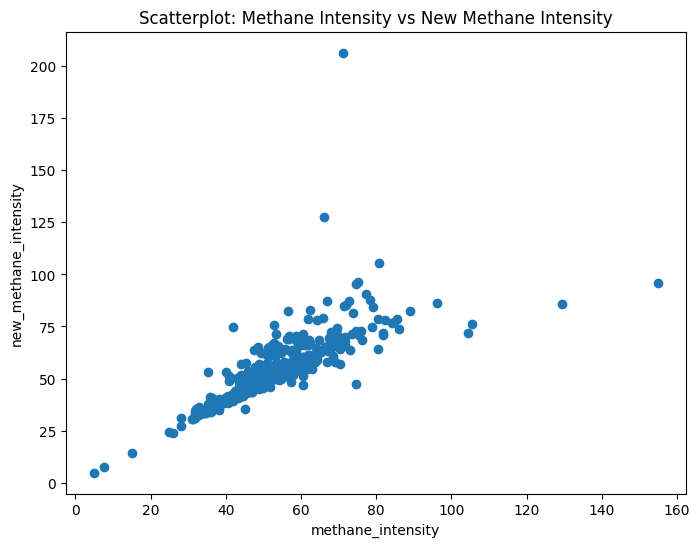

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    calculated_gas["methane_intensity"],
    calculated_gas["new_methane_intensity"]
)

plt.xlabel("methane_intensity")
plt.ylabel("new_methane_intensity")
plt.title("Scatterplot: Methane Intensity vs New Methane Intensity")

plt.show()

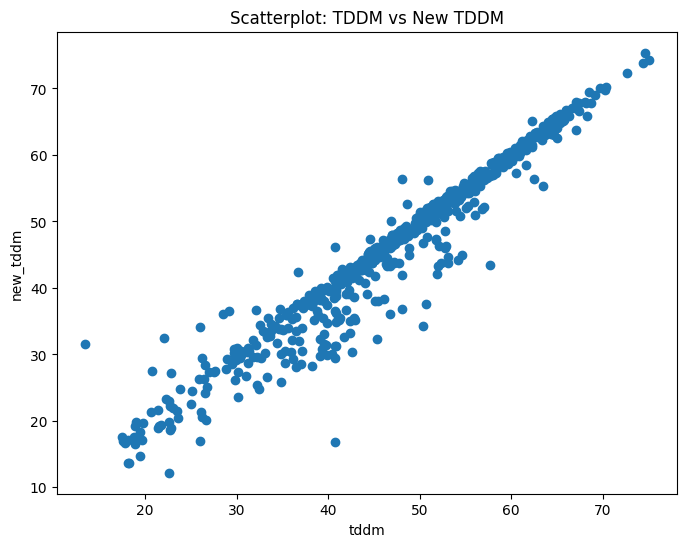

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    calculated_gas["tddm"],
    calculated_gas["new_tddm"]
)

plt.xlabel("tddm")
plt.ylabel("new_tddm")
plt.title("Scatterplot: TDDM vs New TDDM")

plt.show()